# Fake News Detection for the United States Government

## Project Introduction

The project aims to develop a **Machine Learning** model able to classify a news item as **true** or **fake**, with a possible future integration into a Chrome plug-in to support users in recognizing potentially unreliable content.

### Context

The spread of fake news is a relevant problem in the current digital environment.  
The speed with which information circulates online can encourage disinformation phenomena, influencing users, media organizations and institutions.

For this reason, the project analyzes journalistic texts using **Natural Language Processing** and **Machine Learning** techniques, with the goal of identifying textual patterns that are useful for news classification.

### Dataset

The dataset is composed of two separate files:

- `True.csv`: contains true news;
- `Fake.csv`: contains fake news.

Both files include the following information:

- `title`: title of the news item;
- `text`: article content;
- `subject`: thematic category;
- `date`: publication date.

After importing the files, the two datasets are combined into a single DataFrame and the target variable `label` is created, allowing true news and fake news to be distinguished.

### Analysis Objectives

The project focuses on the following objectives:

- analyzing the structure of the datasets;
- checking the distribution between true news and fake news;
- identifying categories and topics most associated with fake news;
- analyzing possible recurring patterns in titles;
- handling duplicates, empty texts and data anomalies;
- reducing possible data leakage risks;
- preparing text for modeling through NLP techniques;
- training and comparing classification models;
- evaluating performance through accuracy, precision, recall and F1-score;
- exporting the final model in pickle format.

### Methodological Approach

The work is organized into several phases:

1. **Exploratory data analysis**, to understand dataset structure, classes, categories and data quality.
2. **Cleaning and preprocessing**, to handle duplicates, empty texts, anomalies and potentially problematic references.
3. **Textual feature engineering**, through TF-IDF text transformation.
4. **Model training and comparison**, with Logistic Regression and Linear SVM.
5. **Final model validation**, through classification metrics and additional checks.
6. **Model export**, for possible future integration into the Chrome plug-in.

### Purpose

The project aims to build an effective, interpretable model that is consistent with the application context required by the project brief, considering not only performance but also data quality and the possible biases present in the dataset.


# First Phase: Data Analysis

In this initial phase, we analyze the provided datasets in order to understand the structure of the data, the available variables and the main characteristics of true and fake news.

The objective is to prepare a solid foundation for the next phases of the project, namely data cleaning, textual exploration and Machine Learning model training.


## Working Environment Preparation

In this first step, we prepare the project working environment by importing the required libraries, configuring the main paths and setting up a support cache.

The cache is used only to make notebook execution more efficient and reproducible, avoiding unnecessary repetition of some heavier operations such as data loading, text cleaning, TF-IDF vectorization and model training.

The dataset files will then be extracted and the two provided datasets will be loaded:

- `Fake.csv`, containing fake news;
- `True.csv`, containing true news.


## Library Import

In this setup cell, we import the libraries required to manage the project.

The libraries are used to:

- define paths compatible with local Jupyter and Google Colab;
- manage the cache for the most computationally expensive steps;
- read and manipulate data;
- build Machine Learning pipelines;
- apply TF-IDF transformation to texts;
- train and evaluate classification models.

This separation makes the notebook easier to read and clearly distinguishes the setup phase from the later loading, analysis and modeling phases.


In [66]:
from pathlib import Path
from joblib import Memory
from types import SimpleNamespace
from collections import Counter
from urllib.request import urlretrieve
import inspect
import hashlib
import sys
import re
import zipfile
import pickle
import importlib
import subprocess

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer, ENGLISH_STOP_WORDS
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

## Working Environment Configuration

In this cell, we configure the main project paths so that the notebook can work both in a local environment and on Google Colab.

Folders are created for the data, the cache and the final models. The cache is used to speed up heavier operations such as text vectorization, cross-validation and some model training steps.

The `verbose=0` option keeps the cache active without showing overly long technical messages in the outputs, making the notebook cleaner and easier to read.


In [67]:
# Portable setup for local Jupyter and Google Colab
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    PROJECT_DIR = Path("/content/fake_news_project")
else:
    PROJECT_DIR = Path.cwd() / "fake_news_project"

DATA_DIR = PROJECT_DIR / "fake_news_data"
ZIP_PATH = PROJECT_DIR / "fake_news.zip"
CACHE_DIR = PROJECT_DIR / "_cache_fake_news"
MODELS_DIR = PROJECT_DIR / "models"

PROJECT_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

CLEAR_CACHE = False

memory = Memory(location=CACHE_DIR, verbose=0)

if CLEAR_CACHE:
    memory.clear(warn=False)

print("Colab environment:", IN_COLAB)
print("Project folder:", PROJECT_DIR)
print("Data folder:", DATA_DIR)
print("Cache folder:", CACHE_DIR)
print("Models folder:", MODELS_DIR)

Colab environment: True
Project folder: /content/fake_news_project
Data folder: /content/fake_news_project/fake_news_data
Cache folder: /content/fake_news_project/_cache_fake_news
Models folder: /content/fake_news_project/models


## Cache Support Functions

In this cell, we define several helper functions mainly used to make cache management more robust.

These functions are used to:

- identify possible changes in loaded files;
- check whether function code has changed;
- create technical signatures that can invalidate the cache when needed;
- read the CSV files containing true and fake news;
- apply the text cleaning function in a cache-compatible way.

This organization avoids unnecessary recomputation in the notebook's heaviest operations and makes the code more organized and reusable.


In [68]:
def file_signature(path):
    """
    Creates a file description using path, size and last modification time.
    It helps the cache understand whether the file has changed.
    """
    path = Path(path)
    stat = path.stat()
    return {
        "path": str(path.resolve()),
        "size": stat.st_size,
        "mtime": stat.st_mtime,
    }


def code_source(obj):
    """
    Retrieves the source code of a function or Python object.
    If the source code is not available, it returns a textual representation.
    """
    try:
        return inspect.getsource(obj)
    except OSError:
        return repr(obj)


def code_signature(*objects, extra=""):
    """
    Creates a code signature using a hash.
    It helps the cache understand whether a function or parameter has changed.
    """
    parts = [str(extra)]
    for obj in objects:
        parts.append(code_source(obj))

    raw = "\n---\n".join(parts)
    return hashlib.sha256(raw.encode("utf-8")).hexdigest()


def read_news_data(fake_csv_path, true_csv_path, fake_sig=None, true_sig=None):
    """
    Reads the CSV files containing fake news and true news.
    The fake_sig and true_sig parameters help the cache detect possible file changes.
    """
    fake_df = pd.read_csv(fake_csv_path)
    true_df = pd.read_csv(true_csv_path)
    return fake_df, true_df


def clean_content_from_source(content_series, clean_text_source):
    """
    Applies the text cleaning function to a content column.
    It is written this way to work correctly with the cache.
    """
    namespace = {"re": re}

    if isinstance(clean_text_source, str) and "def clean_text" in clean_text_source:
        exec(clean_text_source, namespace)
        clean_text_function = namespace["clean_text"]
    else:
        clean_text_function = globals().get("clean_text")

    if clean_text_function is None:
        raise ValueError("The clean_text function is not available.")

    return content_series.apply(clean_text_function)

## Modeling Functions

In this cell, we define the functions used during the Machine Learning phase.

The functions make it possible to:

- apply TF-IDF transformation to texts;
- train classification models;
- run cross-validation;
- compare different Linear SVM model configurations;
- build the final pipeline to export.

Some of these functions are used together with the cache, so that heavy calculations are not repeated during vectorization, validation and model training.

Separating these functions from the rest of the notebook makes the project logic clearer and makes the modeling phase easier to read.


In [69]:
def svm_cross_validation(
    X_train_data,
    y_train_data,
    train_size,
    random_state,
    cv_splits,
    tfidf_params,
    model_params,
    scoring
):
    """
    Runs cross-validation for the Linear SVM model.
    It uses only part of the training set to make the computation faster.
    """
    X_train_cv, _, y_train_cv, _ = train_test_split(
        X_train_data,
        y_train_data,
        train_size=train_size,
        random_state=random_state,
        stratify=y_train_data
    )

    cv = StratifiedKFold(
        n_splits=cv_splits,
        shuffle=True,
        random_state=random_state
    )

    pipeline_svm_cv = Pipeline([
        ("tfidf", TfidfVectorizer(**tfidf_params)),
        ("model", LinearSVC(**model_params))
    ])

    scores = cross_validate(
        pipeline_svm_cv,
        X_train_cv,
        y_train_cv,
        cv=cv,
        scoring=scoring,
        n_jobs=1
    )

    return scores, len(X_train_cv)


def tfidf_vectorize(X_train_data, X_test_data, tfidf_params):
    """
    Transforms texts into numbers using TF-IDF.
    The vectorizer is learned only on the training set and then applied to the test set.
    """
    vectorizer = TfidfVectorizer(**tfidf_params)
    X_train_matrix = vectorizer.fit_transform(X_train_data)
    X_test_matrix = vectorizer.transform(X_test_data)
    return vectorizer, X_train_matrix, X_test_matrix


def train_logistic_model(X_train_matrix, y_train_data, model_params):
    """
    Trains a Logistic Regression model on training data already transformed with TF-IDF.
    """
    model = LogisticRegression(**model_params)
    model.fit(X_train_matrix, y_train_data)
    return model


def train_svm_model(X_train_matrix, y_train_data, model_params):
    """
    Trains a Linear SVM model on training data already transformed with TF-IDF.
    """
    model = LinearSVC(**model_params)
    model.fit(X_train_matrix, y_train_data)
    return model


def train_text_and_style_svm_pipeline(
    X_train_data,
    y_train_data,
    tfidf_params,
    numeric_features,
    model_params,
    training_signature=None
):
    """
    Trains a Linear SVM pipeline that uses both cleaned text and selected stylistic variables.
    Stylistic variables may include information such as title length or punctuation.
    """
    preprocessor_text_and_style = ColumnTransformer(
        transformers=[
            (
                "tfidf",
                TfidfVectorizer(**tfidf_params),
                "clean_content"
            ),
            (
                "style_features",
                StandardScaler(with_mean=False),
                list(numeric_features)
            )
        ]
    )

    text_and_style_pipeline = Pipeline([
        ("preprocessor", preprocessor_text_and_style),
        ("model", LinearSVC(**model_params))
    ])

    text_and_style_pipeline.fit(X_train_data, y_train_data)

    return text_and_style_pipeline


def fast_linear_svm_optimization(
    X_train_data,
    y_train_data,
    train_size,
    test_size,
    random_state,
    parameter_grid,
    optimization_signature=None
):
    """
    Quickly compares different Linear SVM configurations.
    Returns a table with the metrics and the best parameters found.
    """
    X_train_fast, X_valid_fast, y_train_fast, y_valid_fast = train_test_split(
        X_train_data,
        y_train_data,
        train_size=train_size,
        test_size=test_size,
        random_state=random_state,
        stratify=y_train_data
    )

    results = []

    for params in parameter_grid:
        pipeline_temp = Pipeline([
            ("tfidf", TfidfVectorizer(
                stop_words="english",
                max_features=params["max_features"],
                ngram_range=tuple(params["ngram_range"])
            )),
            ("model", LinearSVC(
                C=params["C"],
                random_state=random_state,
                max_iter=3000
            ))
        ])

        pipeline_temp.fit(X_train_fast, y_train_fast)
        y_valid_pred = pipeline_temp.predict(X_valid_fast)

        results.append({
            "max_features": params["max_features"],
            "ngram_range": tuple(params["ngram_range"]),
            "C": params["C"],
            "accuracy": accuracy_score(y_valid_fast, y_valid_pred),
            "precision_fake": precision_score(y_valid_fast, y_valid_pred, pos_label=1),
            "recall_fake": recall_score(y_valid_fast, y_valid_pred, pos_label=1),
            "f1_fake": f1_score(y_valid_fast, y_valid_pred, pos_label=1)
        })

    results_df = (
        pd.DataFrame(results)
        .sort_values("f1_fake", ascending=False)
        .reset_index(drop=True)
    )

    best_row = results_df.iloc[0]
    best_params = {
        "max_features": int(best_row["max_features"]),
        "ngram_range": tuple(best_row["ngram_range"]),
        "C": float(best_row["C"])
    }

    return results_df, best_params


def train_final_linear_svm_pipeline(
    X_train_data,
    y_train_data,
    best_params,
    random_state,
    training_signature=None
):
    """
    Trains the final Linear SVM pipeline using the selected parameters.
    This pipeline includes TF-IDF and the final model in a single object.
    """
    final_pipeline = Pipeline([
        ("tfidf", TfidfVectorizer(
            stop_words="english",
            max_features=int(best_params["max_features"]),
            ngram_range=tuple(best_params["ngram_range"])
        )),
        ("model", LinearSVC(
            C=float(best_params["C"]),
            random_state=random_state,
            max_iter=3000
        ))
    ])

    final_pipeline.fit(X_train_data, y_train_data)

    return final_pipeline

## Preparation of Cached Functions

In this cell, we connect the previously defined functions to the cache system.

This step allows the results of slower operations to be temporarily stored, avoiding recalculation every time the notebook is rerun.

The cache is applied to functions used for data reading, text cleaning, TF-IDF transformation, validation and model training.


In [70]:
# Objects compatible with the following notebook cells
cache_utils = SimpleNamespace(
    read_news_data=read_news_data,
    clean_content_from_source=clean_content_from_source,
    svm_cross_validation=svm_cross_validation,
    tfidf_vectorize=tfidf_vectorize,
    train_logistic_model=train_logistic_model,
    train_svm_model=train_svm_model,
    train_text_and_style_svm_pipeline=train_text_and_style_svm_pipeline
)

optimization_cache_utils = SimpleNamespace(
    fast_linear_svm_optimization=fast_linear_svm_optimization,
    train_final_linear_svm_pipeline=train_final_linear_svm_pipeline
)

cached_read_news_data = memory.cache(read_news_data)
cached_clean_content = memory.cache(clean_content_from_source)
cached_svm_cross_validation = memory.cache(svm_cross_validation)
cached_tfidf_vectorize = memory.cache(tfidf_vectorize)
cached_train_logistic_model = memory.cache(train_logistic_model)
cached_train_svm_model = memory.cache(train_svm_model)
cached_train_text_and_style_svm_pipeline = memory.cache(train_text_and_style_svm_pipeline)
cached_fast_linear_svm_optimization = memory.cache(fast_linear_svm_optimization)
cached_train_final_linear_svm_pipeline = memory.cache(train_final_linear_svm_pipeline)

### Download, Extraction and Loading of the Datasets

In this cell, we prepare the files required to begin the data analysis.

The code first checks whether the compressed file `fake_news.zip` is already present in the project folder. If the file is not available, it is downloaded automatically from the link provided in the project brief.

The contents of the compressed file are then extracted into the data folder, producing the two main project files:

- `Fake.csv`, containing fake news;
- `True.csv`, containing true news.

Finally, the two datasets are loaded through a cached function, avoiding unnecessary reloading in later notebook executions.


In [71]:
DATASET_URL = "https://proai-datasets.s3.eu-west-3.amazonaws.com/fake_news.zip"

fake_csv_path = DATA_DIR / "Fake.csv"
true_csv_path = DATA_DIR / "True.csv"

# Download the dataset if it is not already available
if not ZIP_PATH.exists():
    print("Downloading the dataset...")
    urlretrieve(DATASET_URL, ZIP_PATH)
    print("Download completed:", ZIP_PATH)

# Extract the CSV files if they are not already available
if not fake_csv_path.exists() or not true_csv_path.exists():
    print("Extracting the dataset...")
    with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
        zip_ref.extractall(DATA_DIR)
    print("Extraction completed:", DATA_DIR)

fake_df, true_df = cached_read_news_data(
    fake_csv_path,
    true_csv_path,
    file_signature(fake_csv_path),
    file_signature(true_csv_path)
)

display(fake_df.head())
display(true_df.head())


,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


### Observations on Dataset Loading

The output shows the first five rows of both datasets.

The first dataset, `fake_df`, contains fake news, while the second dataset, `true_df`, contains true news. Both have the same structure, composed of four columns:

- `title`: the title of the news item;
- `text`: the textual content of the news item;
- `subject`: the category or topic of the news item;
- `date`: the publication date.

This common structure is useful because it allows the two datasets to be merged later into a single DataFrame, adding a classification column that indicates whether each news item is fake or true.

From the first rows, it is also possible to notice that the true news dataset often contains the Reuters source reference at the beginning of the text, while the fake news dataset has texts with an apparently more narrative or sensationalistic style. This is only a first qualitative observation, which will need to be examined through more systematic analyses in the following cells.


### Check of Dimensions and Columns

After correctly loading the datasets, it is useful to check their dimensions and column structure.

This step makes it possible to verify:

- how many fake and true news items are present;
- how many variables each dataset contains;
- whether the two datasets have the same structure;
- which columns will be available for the following analysis.


In [72]:
print("Fake news dataset dimensions:", fake_df.shape)
print("True news dataset dimensions:", true_df.shape)

print("\nFake news dataset columns:")
print(fake_df.columns)

print("\nTrue news dataset columns:")
print(true_df.columns)

Fake news dataset dimensions: (23481, 4)
True news dataset dimensions: (21417, 4)

Fake news dataset columns:
Index(['title', 'text', 'subject', 'date'], dtype='object')

True news dataset columns:
Index(['title', 'text', 'subject', 'date'], dtype='object')


### Observations on Dimensions and Columns

The check shows that the fake news dataset contains **23,481 rows** and **4 columns**, while the true news dataset contains **21,417 rows** and **4 columns**.

Both datasets therefore have the same structure and contain the same columns:

- `title`: news title;
- `text`: textual content of the news item;
- `subject`: category or topic of the news item;
- `date`: publication date.

This structural consistency is important because it allows the two datasets to be merged into a single DataFrame. Before merging them, however, it will be necessary to add a target column, that is, a variable that distinguishes fake news from true news.


## Addition of the Target Variable and Dataset Merging

In order to train a Machine Learning model later, the dataset must indicate the correct class for each observation.

We therefore add a new column called `label`:

- `1` for fake news;
- `0` for true news.

After creating this target variable, we merge the two datasets into a single DataFrame. In this way, we obtain one table containing both fake news and true news.


In [73]:
fake_df["label"] = 1
true_df["label"] = 0

df = pd.concat([fake_df, true_df], ignore_index=True)

display(df.head())
display(df.tail())

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",1
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",1
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",1
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",1
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",1


,title,text,subject,date,label
44893,'Fully committed' NATO backs new U.S. approach...,BRUSSELS (Reuters) - NATO allies on Tuesday we...,worldnews,"August 22, 2017",0
44894,LexisNexis withdrew two products from Chinese ...,"LONDON (Reuters) - LexisNexis, a provider of l...",worldnews,"August 22, 2017",0
44895,Minsk cultural hub becomes haven from authorities,MINSK (Reuters) - In the shadow of disused Sov...,worldnews,"August 22, 2017",0
44896,Vatican upbeat on possibility of Pope Francis ...,MOSCOW (Reuters) - Vatican Secretary of State ...,worldnews,"August 22, 2017",0
44897,Indonesia to buy $1.14 billion worth of Russia...,JAKARTA (Reuters) - Indonesia will buy 11 Sukh...,worldnews,"August 22, 2017",0


### Observations on the Target Variable and Dataset Merging

The output shows that the `label` column has been correctly added to the data.

The first rows of the unified DataFrame contain fake news, identified by the value:

- `label = 1`

The last rows instead contain true news, identified by the value:

- `label = 0`

The new DataFrame `df` therefore contains both classes of the problem and will be the working basis for the following exploratory analyses.

The index reaches `44897`, so the unified dataset contains **44,898 observations** in total. This number corresponds to the sum of the rows in the two original datasets:

- 23,481 fake news;
- 21,417 true news.


## Dataset Shuffling

After checking that the two datasets were merged correctly, we proceed to randomly shuffle the rows of the DataFrame.

This operation is useful because, after concatenation, the dataset is ordered by class: fake news first and true news afterward. Shuffling the rows produces a dataset that is more suitable for the following analysis and modeling phases, avoiding the possibility that the original order of the data influences later processing.


In [74]:
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

display(df.head())
display(df.tail())

,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",1
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",0
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",0
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",1
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",0


,title,text,subject,date,label
44893,UNREAL! CBS’S TED KOPPEL Tells Sean Hannity He...,,politics,"Mar 27, 2017",1
44894,PM May seeks to ease Japan's Brexit fears duri...,LONDON/TOKYO (Reuters) - British Prime Ministe...,worldnews,"August 29, 2017",0
44895,Merkel: Difficult German coalition talks can r...,BERLIN (Reuters) - Chancellor Angela Merkel sa...,worldnews,"November 16, 2017",0
44896,Trump Stole An Idea From North Korean Propaga...,Jesus f*cking Christ our President* is a moron...,News,"July 14, 2017",1
44897,BREAKING: HILLARY CLINTON’S STATE DEPARTMENT G...,IF SHE S NOT TOAST NOW THEN WE RE IN BIGGER TR...,politics,"Apr 23, 2015",1


### Observations on Dataset Shuffling

The output shows the first and last five rows of the DataFrame after random shuffling.

Unlike the previous phase, where the dataset was ordered by class, fake news and true news are now randomly distributed inside the DataFrame. This can be observed from the `label` column, where both values `1`, corresponding to fake news, and values `0`, corresponding to true news, appear.

Shuffling does not modify the content of the observations; it only changes the order of the rows. This operation is useful because it makes the dataset more suitable for the following analysis and modeling phases, avoiding the possibility that the original data order influences later processing.


## Check of Class Distribution

After merging and shuffling the datasets, we analyze the distribution of the target variable `label`.

This check makes it possible to understand whether the dataset contains a similar number of fake news and true news items or whether one class is much more represented than the other.

Class distribution is important because excessive imbalance could affect model training and the evaluation of its performance.


In [75]:
class_counts = df["label"].value_counts()
class_percentages = df["label"].value_counts(normalize=True) * 100

class_distribution = pd.DataFrame({
    "count": class_counts,
    "percentage": class_percentages
})

class_distribution

,count,percentage
label,,
1,23481,52.298543
0,21417,47.701457


### Observations on Class Distribution

The output shows the distribution of the target variable `label` in the unified dataset:

- `1`: 23,481 fake news items, about 52.30% of the dataset;
- `0`: 21,417 true news items, about 47.70% of the dataset.

The dataset is therefore fairly balanced, because the number of fake news and true news items is similar.

This is a positive aspect for the modeling phase, since the model will have a comparable number of examples for both classes. With highly imbalanced classes, the model could instead learn to favor the majority class, obtaining apparently good but unreliable results.


## Visualization of Class Distribution

After numerically checking the distribution of the `label` variable, we represent the same result with a bar chart.

The graphical visualization makes it easier to compare the number of fake news and true news items present in the dataset.


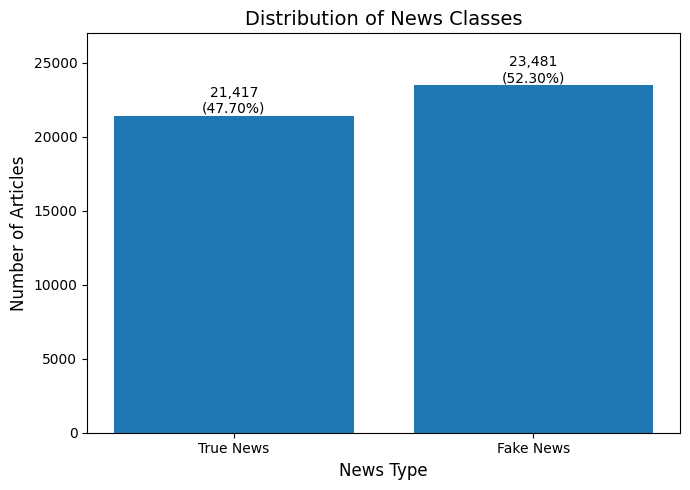

In [76]:
class_counts = df["label"].value_counts().sort_index()
class_percentages = df["label"].value_counts(normalize=True).sort_index() * 100

class_labels = ["True News", "Fake News"]

plt.figure(figsize=(7, 5))
bars = plt.bar(class_labels, class_counts)

plt.title("Distribution of News Classes", fontsize=14)
plt.xlabel("News Type", fontsize=12)
plt.ylabel("Number of Articles", fontsize=12)

plt.ylim(0, class_counts.max() * 1.15)

for bar, count, percentage in zip(bars, class_counts, class_percentages):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count:,}\n({percentage:.2f}%)",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()

### Observations on the Class Distribution Chart

The bar chart shows the distribution of the two classes in the dataset:

- `True News`: true news;
- `Fake News`: fake news.

The chart shows that the number of fake news items is slightly higher than the number of true news items. However, the difference is not excessive, so the dataset can be considered fairly balanced.

This information is important because a balanced dataset helps the Machine Learning model learn both classes more evenly, reducing the risk that it favors only the majority class.


## Check of Missing Values

Before proceeding with deeper analyses, it is necessary to check for missing values in the dataset.

Missing values may indicate absent information in some columns, such as unavailable titles, empty texts, missing categories or unrecorded dates.

This check makes it possible to understand whether cleaning operations will be required before the modeling phase.


In [77]:
df.isnull().sum()

,0
title,0
text,0
subject,0
date,0
label,0


### Observations on Missing Values

The output shows that there are no missing values in the dataset.

For all columns, the null value count is equal to `0`:

- `title`: 0 missing values;
- `text`: 0 missing values;
- `subject`: 0 missing values;
- `date`: 0 missing values;
- `label`: 0 missing values.

This means that, from the point of view of explicit null values, the dataset is complete.

However, this check is not sufficient to completely rule out data problems. A cell may not be formally null, but may contain an empty string or a space. For this reason, the next analyses will also check for empty or low-information texts.


## Check of Empty Texts

After verifying the absence of explicit missing values, we check whether the `text` column contains empty strings.

This step is important because, in a Natural Language Processing project, textual content represents one of the main sources of information for training the model.

A news item without text, even if it is not formally missing, may be of limited use for the modeling phase.


In [78]:
empty_text_count = (df["text"].str.strip() == "").sum()

print("Total number of empty texts:", empty_text_count)

empty_text_by_class = (
    df[df["text"].str.strip() == ""]["label"]
    .value_counts()
    .reindex([0, 1], fill_value=0)
)

empty_text_summary = pd.DataFrame({
    "News class": ["True News", "Fake News"],
    "Empty text count": empty_text_by_class.values
})

display(empty_text_summary)

Total number of empty texts: 631


,News class,Empty text count
0,True News,1
1,Fake News,630


### Observations on Empty Texts

The check shows that the dataset contains **631 rows** where the `text` column is empty.

In particular, the distribution by class shows that:

- **True News**: 1 empty text;
- **Fake News**: 630 empty texts.

This result is important because, although there are no explicit missing values, some news items do not have useful textual content in the main column used for NLP analysis.

In addition, the fact that almost all empty texts belong to the fake news class is an aspect that must be considered carefully, because the model could indirectly learn a shortcut based on the absence of text.

The presence of empty texts does not necessarily mean that these rows should be removed immediately. In some cases, the news title may still contain useful information for classification.

For this reason, before deciding how to handle these observations, it will also be useful to analyze the `title` column and check whether titles are present and informative.


## Check of Empty Titles

After identifying the presence of empty texts, we check whether the `title` column also contains empty strings.

This check is useful because the title can represent an important source of information, especially in cases where the body of the news item is not available.

If titles are complete, we can later consider combining `title` and `text` into a single textual variable.


In [79]:
empty_title_count = (df["title"].str.strip() == "").sum()

print("Number of empty titles:", empty_title_count)

Number of empty titles: 0


### Observations on Empty Titles

The check shows that there are no empty titles in the dataset.

This result is positive because all news items have at least one available title. Even when the news body is empty, the `title` column can therefore provide useful textual information.

For the next phases of the project, this observation suggests that it may be useful to create a single textual variable by combining the news title and text.


## Check of Duplicates

After checking missing values, empty texts and empty titles, we verify the presence of duplicate rows in the dataset.

Duplicates can be problematic because they repeat the same information multiple times. In a Machine Learning project, this could affect model training by making the model give excessive importance to some news items over others.

At this stage, we only count duplicates without removing them immediately. The decision about removal will be made after evaluating the size of the problem.


In [80]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 209


### Observations on Duplicates

The check shows the presence of **209 duplicate rows** in the dataset.

This means that some news items appear more than once with the same values in all considered columns.

The presence of duplicates may negatively affect the following phases, because the model could see the same content multiple times during training. This risks giving excessive weight to some news items and making the evaluation less reliable.

Before proceeding to modeling, it will therefore be appropriate to remove duplicates, keeping only one copy of each news item.


## Check of Duplicates Based on Title and Text

After counting fully duplicate rows, we check for duplicates considering only the `title` and `text` columns.

This step is useful because, in an NLP project, the textual content of the news item represents the main information used by the model.

Two rows may have the same title and the same text, but differ in other columns such as `date` or `subject`. In these cases, from a textual point of view, the news item would still be duplicated.


In [81]:
text_duplicate_count = df.duplicated(subset=["title", "text"]).sum()

print("Number of duplicate rows based on title and text, excluding the first occurrence:", text_duplicate_count)

text_duplicates_by_class = (
    df[df.duplicated(subset=["title", "text"], keep=False)]["label"]
    .value_counts()
    .reindex([0, 1], fill_value=0)
)

text_duplicates_summary = pd.DataFrame({
    "News class": ["True News", "Fake News"],
    "Rows involved in duplicate groups": text_duplicates_by_class.values
})

display(text_duplicates_summary)

Number of duplicate rows based on title and text, excluding the first occurrence: 5793


,News class,Rows involved in duplicate groups
0,True News,427
1,Fake News,10671


## Observations on Textual Duplicates

The check shows the presence of **5,793 duplicates** when considering only the `title` and `text` columns.

This number is much higher than the number of complete duplicates identified earlier. This means that many news items have the same textual content, even if they may differ in other information such as date or category.

Analyzing textual duplicates by class, it emerges that they are mainly concentrated among fake news. In particular, among the observations involved in duplicate groups, there are **10,671 rows associated with Fake News** and **427 rows associated with True News**.

It is important to clarify that the value **5,793** represents the number of duplicate rows beyond the first occurrence, while the class distribution considers all rows involved in duplicate groups, including the first occurrences.

For this reason, the two counts do not have to match: the first measures how many rows would be removed by textual duplicate removal, while the second describes how many total observations belong to repeated contents.

In a Natural Language Processing project, this aspect is especially relevant because the model works mainly on texts. If the same news item appears multiple times, especially within one class, the model could overlearn specific contents, reducing its ability to generalize to new news items.

For this reason, during the cleaning phase it will be appropriate to remove duplicates based at least on the `title` and `text` columns, while also monitoring the effect of removal on class distribution.


## Check of Duplicates with Conflicting Labels

After analyzing textual duplicates, we check whether there are contents with the same `title` and the same `text` but associated with different classes.

This check is important because, in a classification project, the presence of the same textual content labeled both as fake news and as true news could create ambiguity during model training.


In [82]:
conflicting_duplicates = (
    df.groupby(["title", "text"])["label"]
    .nunique()
    .reset_index(name="num_labels")
)

conflicting_duplicates = conflicting_duplicates[conflicting_duplicates["num_labels"] > 1]

print("Number of textual contents with conflicting labels:", conflicting_duplicates.shape[0])

Number of textual contents with conflicting labels: 0


### Observations on Duplicates with Conflicting Labels

The check shows that the number of textual contents with conflicting labels is equal to **0**.

This means that there are no cases where the same news item, identified by the `title` and `text` columns, was classified both as fake news and as true news.

The result is positive because it indicates that the textual duplicates identified earlier do not introduce direct contradictions into the target variable `label`.

It remains appropriate to handle duplicates during the cleaning phase, since their presence can affect model training and lead it to memorize repeated content instead of learning general linguistic patterns.


### Creation of a Clean Version of the Dataset

After identifying textual duplicates, it is appropriate to create a first clean version of the dataset.

Removal is performed using the `title` and `text` columns because, in the context of an NLP project, two news items with the same title and the same text represent the same information content, even if they may have different values in other columns such as `date` or `subject`.

This operation is important because duplicates could affect both exploratory analysis and, especially, the model training phase. If the same content appeared in both the training set and the test set, the model could obtain artificially high performance not because it is truly able to generalize, but because it has already seen identical content during training.

For this reason, a new DataFrame called `df_clean` is created and will be used as the basis for the following cleaning, text preprocessing and modeling phases.


In [83]:
# Creation of a clean copy of the dataset by removing textual duplicates
df_clean = df.drop_duplicates(subset=["title", "text"]).reset_index(drop=True).copy()

print("Original dataset dimensions:")
print(df.shape)

print("\nDataset dimensions after removing textual duplicates:")
print(df_clean.shape)

print("\nNumber of removed rows:")
print(df.shape[0] - df_clean.shape[0])

class_counts_after_deduplication = (
    df_clean["label"]
    .value_counts()
    .reindex([0, 1])
)

class_percentages_after_deduplication = (
    df_clean["label"]
    .value_counts(normalize=True)
    .reindex([0, 1]) * 100
)

class_distribution_after_deduplication = pd.DataFrame({
    "News class": ["True News", "Fake News"],
    "Number of articles": class_counts_after_deduplication.values,
    "Percentage": class_percentages_after_deduplication.round(2).values
})

print("\nClass distribution after removing textual duplicates:")
display(class_distribution_after_deduplication)

Original dataset dimensions:
(44898, 5)

Dataset dimensions after removing textual duplicates:
(39105, 5)

Number of removed rows:
5793

Class distribution after removing textual duplicates:


,News class,Number of articles,Percentage
0,True News,21197,54.21
1,Fake News,17908,45.79


### Observations on the Removal of Textual Duplicates

The removal of textual duplicates reduced the dataset from 44,898 observations to 39,105 observations, eliminating a total of 5,793 duplicate rows.

This operation is important because, in a Natural Language Processing project, the presence of the same textual content multiple times could distort both the exploratory analysis and the later modeling phase. In particular, if identical contents were present in both the training set and the test set, the model could obtain artificially high performance based on memorizing already observed texts rather than on a real ability to generalize.

After removing duplicates, the class distribution remains fairly balanced, although with a slight prevalence of true news:

- true news represents 54.21% of the dataset;
- fake news represents 45.79% of the dataset.

This change shows that duplicates were not uniformly distributed between the two classes, but were more frequent in the fake news class.

From this point onward, the DataFrame `df_clean` will be used as the reference version of the dataset for the following exploratory analyses, text cleaning and modeling phase.


### Check of Empty Texts in the Clean Dataset

After removing textual duplicates, it is useful to check again for empty texts in the `text` column.

This check makes it possible to understand whether the problem of absent texts is still present in the clean version of the dataset and whether it mainly affects one of the two classes.

Since the NLP model will work mainly on the textual content of the news items, the presence of empty texts will need to be considered during the preprocessing phase.


In [84]:
empty_text_clean_count = (df_clean["text"].str.strip() == "").sum()

empty_text_clean_by_class = (
    df_clean[df_clean["text"].str.strip() == ""]["label"]
    .value_counts()
    .reindex([0, 1], fill_value=0)
)

empty_text_clean_summary = pd.DataFrame({
    "News class": ["True News", "Fake News"],
    "Empty text count": empty_text_clean_by_class.values
})

print("Number of empty texts in the clean dataset:")
print(empty_text_clean_count)

print("\nEmpty texts by class in the clean dataset:")
display(empty_text_clean_summary)

Number of empty texts in the clean dataset:
447

Empty texts by class in the clean dataset:


,News class,Empty text count
0,True News,1
1,Fake News,446


## Observations on Empty Texts in the Clean Dataset

The check shows that, even after removing textual duplicates, the clean dataset still contains **447 empty texts** in the `text` column.

The distribution by class shows that the problem almost exclusively concerns fake news:

- **446 empty texts** belong to **Fake News**;
- **1 empty text** belongs to **True News**.

This result confirms that the absence of the text body is not uniformly distributed between the two classes. Therefore, during preprocessing, these observations will need to be handled carefully because the model could indirectly learn a shortcut based on the absence of text.

The later creation of the `content` variable, obtained by combining `title` and `text`, will be useful because it will still preserve the news title even when the text body is empty.


## Analysis of the `date` Column

After analyzing duplicates, we check the `date` column, which contains the publication date of the news items.

This check is useful to verify whether dates are written consistently and whether they can be correctly converted into a time format usable by Python.

At this stage, the `date` column is analyzed only for exploratory purposes, because the main objective of the project is to build an NLP model based on the textual content of the news items.


In [85]:
print("First 10 dates in the clean dataset:")
display(df_clean["date"].head(10))

df_clean["date_clean"] = pd.to_datetime(
    df_clean["date"].astype(str).str.strip(),
    errors="coerce",
    format="mixed"
)

print("Number of non-convertible dates:", df_clean["date_clean"].isnull().sum())
print("Minimum date:", df_clean["date_clean"].min())
print("Maximum date:", df_clean["date_clean"].max())

First 10 dates in the clean dataset:


,date
0,"February 13, 2017"
1,"April 5, 2017"
2,"September 27, 2017"
3,"May 22, 2017"
4,"June 24, 2016"
5,"June 22, 2016"
6,"Feb 19, 2017"
7,"Mar 8, 2016"
8,"December 13, 2017"
9,"May 4, 2016"


Number of non-convertible dates: 6
Minimum date: 2015-03-31 00:00:00
Maximum date: 2018-02-19 00:00:00


## Observations on the Analysis of the `date` Column

The output shows that the `date` column contains dates written in formats that are not fully uniform, for example with months written in full, such as `February 13, 2017`, or abbreviated, such as `Feb 19, 2017`.

After conversion to a time format, there are **6 non-convertible dates**. This value is very low compared with the overall size of the clean dataset, but it still indicates the presence of some observations with anomalous or non-interpretable values in the `date` column.

The period covered by the dataset ranges from **March 31, 2015** to **February 19, 2018**.

At this stage, the `date` column is mainly kept for exploratory purposes. Before using it in possible deeper temporal analyses, it will be appropriate to inspect the 6 non-convertible dates and decide whether to correct or exclude them.


In [86]:
invalid_dates = df_clean[df_clean["date_clean"].isnull()]["date"].unique()

print("Non-convertible dates in the clean dataset:")
print(invalid_dates)

invalid_date_rows = df_clean[df_clean["date_clean"].isnull()][["title", "text", "subject", "date", "label"]]

invalid_date_rows

Non-convertible dates in the clean dataset:
['https://100percentfedup.com/video-hillary-asked-about-trump-i-just-want-to-eat-some-pie/'
 'https://fedup.wpengine.com/wp-content/uploads/2015/04/entitled.jpg'
 'https://fedup.wpengine.com/wp-content/uploads/2015/04/hillarystreetart.jpg'
 'https://100percentfedup.com/served-roy-moore-vietnamletter-veteran-sets-record-straight-honorable-decent-respectable-patriotic-commander-soldier/'
 'MSNBC HOST Rudely Assumes Steel Worker Would Never Let His Son Follow in His Footsteps…He Couldn’t Be More Wrong [Video]'
 'https://100percentfedup.com/12-yr-old-black-conservative-whose-video-to-obama-went-viral-do-you-really-love-america-receives-death-threats-from-left/']


,title,text,subject,date,label
6276,https://100percentfedup.com/video-hillary-aske...,https://100percentfedup.com/video-hillary-aske...,politics,https://100percentfedup.com/video-hillary-aske...,1
7199,https://fedup.wpengine.com/wp-content/uploads/...,https://fedup.wpengine.com/wp-content/uploads/...,left-news,https://fedup.wpengine.com/wp-content/uploads/...,1
9008,https://fedup.wpengine.com/wp-content/uploads/...,https://fedup.wpengine.com/wp-content/uploads/...,Government News,https://fedup.wpengine.com/wp-content/uploads/...,1
10529,https://100percentfedup.com/served-roy-moore-v...,https://100percentfedup.com/served-roy-moore-v...,politics,https://100percentfedup.com/served-roy-moore-v...,1
18258,Homepage,[vc_row][vc_column width= 1/1 ][td_block_trend...,left-news,MSNBC HOST Rudely Assumes Steel Worker Would N...,1
23910,https://100percentfedup.com/12-yr-old-black-co...,https://100percentfedup.com/12-yr-old-black-co...,politics,https://100percentfedup.com/12-yr-old-black-co...,1


## Observations on Non-convertible Dates

The check shows that the clean dataset contains **6 non-convertible dates**. These values do not correspond to simple date formats written differently, but to anomalous values present in the `date` column.

In particular, these values include URLs, image references and portions of text that do not represent a valid publication date.

The visualization of the complete rows also shows that, in some cases, the anomaly does not concern only the `date` column, but also other textual columns such as `title` and `text`, where URLs or contents inconsistent with a complete news item appear.

This result confirms that the clean dataset still contains a small number of dirty observations, although they are very limited compared with the overall dataset size.

Since the project is mainly oriented toward fake news classification through NLP techniques, the `date` column will not be used as a main predictive variable.


## Check of Dirty or Low-Information Rows

After identifying some non-convertible dates, we further examine dataset quality by searching for rows that, although not formally missing, may contain information of limited usefulness for an NLP model.

In particular, we check for the presence of:

- URLs in textual fields;
- HTML elements or shortcodes;
- very short texts;
- contents composed only of links.

This check is important because a Machine Learning model could learn shortcuts related to the dirty structure of the dataset instead of focusing on the real content of the news items.


In [87]:
quality_check = df_clean[["title", "text", "subject", "date", "label"]].copy()

combined_text_for_quality = (
    quality_check["title"].astype(str)
    + " "
    + quality_check["text"].astype(str)
    + " "
    + quality_check["date"].astype(str)
)

url_pattern = r"https?://|www\."
html_shortcode_pattern = r"<[^>]+>|\[(?:vc_|td_|/vc_|/td_)[^\]]*\]"
only_link_pattern = r"^(?:https?://\S+|www\.\S+)(?:\s+(?:https?://\S+|www\.\S+))*$"

quality_check["text_word_count"] = quality_check["text"].fillna("").str.split().str.len()

quality_check["has_url"] = combined_text_for_quality.str.contains(
    url_pattern,
    case=False,
    regex=True,
    na=False
)

quality_check["has_html_or_shortcode"] = combined_text_for_quality.str.contains(
    html_shortcode_pattern,
    case=False,
    regex=True,
    na=False
)

quality_check["is_only_link"] = quality_check["text"].fillna("").str.strip().str.contains(
    only_link_pattern,
    case=False,
    regex=True,
    na=False
)

quality_check["is_very_short_text"] = (
    (quality_check["text_word_count"] > 0)
    & (quality_check["text_word_count"] <= 10)
)

dirty_columns = [
    "has_url",
    "has_html_or_shortcode",
    "is_only_link",
    "is_very_short_text"
]

dirty_summary = quality_check[dirty_columns].sum().sort_values(ascending=False)

print("Number of rows with possible quality issues:")
display(dirty_summary)

print("\nDistribution of dirty rows by class:")
display(quality_check.groupby("label")[dirty_columns].sum())

dirty_rows = quality_check[quality_check[dirty_columns].any(axis=1)]

print("\nTotal number of rows with at least one possible quality issue:", dirty_rows.shape[0])

display(
    dirty_rows[
        ["title", "text", "subject", "date", "label", "text_word_count"] + dirty_columns
    ].head(20)
)


Number of rows with possible quality issues:


,0
has_url,2590
is_very_short_text,174
has_html_or_shortcode,69
is_only_link,53



Distribution of dirty rows by class:


,has_url,has_html_or_shortcode,is_only_link,is_very_short_text
label,,,,
0,41,8,0,0
1,2549,61,53,174



Total number of rows with at least one possible quality issue: 2767


,title,text,subject,date,label,text_word_count,has_url,has_html_or_shortcode,is_only_link,is_very_short_text
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",1,183,True,False,False,False
7,STAND UP AND CHEER! UKIP Party Leader SLAMS Ge...,He s been Europe s version of the outspoken Te...,left-news,"Mar 8, 2016",1,299,True,False,False,False
25,It Looks Like The Trump Campaign Just Got Thi...,While Donald Trump accuses Hillary Clinton of ...,News,"September 18, 2016",1,435,True,False,False,False
26,Asian American Organizations RAIN HELL Upon F...,Asian Americans are pissed off after Fox News ...,News,"October 6, 2016",1,755,True,False,False,False
56,WATCH: SEAN HANNITY FANS Make HILARIOUS Videos...,When Keurig decided to side with Soros against...,politics,"Nov 13, 2017",1,686,True,False,False,False
73,Trump Tells China To Keep Our Navy Drone And ...,Donald Trump just proved once again that he is...,News,"December 17, 2016",1,514,True,False,False,False
121,JUST IN: Trump Just Spoke Out On Fate Of UCLA ...,President Trump just spoke out on the fate of ...,politics,"Nov 14, 2017",1,288,True,False,False,False
126,(VIDEO) SICKENING CHALLENGE GOES VIRAL: DISRES...,"A sick new challenge is going viral, urging ...",left-news,"May 1, 2015",1,240,True,False,False,False
134,October Tease: Wikileaks False Start Leaves Tr...,21st Century Wire says This was one of the mos...,Middle-east,"October 4, 2016",1,437,True,False,False,False
144,Watch Out NRA: President Obama Is Coming For You,"Where Congress isn t acting on gun reform, Pre...",News,"April 29, 2016",1,834,True,False,False,False


## Observations on Dirty or Low-Information Rows

The check shows that the clean dataset still contains some rows with possible quality issues, even though they are not explicit missing values.

In particular, the following were identified:

- **2,590 rows** containing at least one URL;
- **174 rows** with very short text;
- **69 rows** containing HTML elements or shortcodes;
- **53 rows** where the textual content is composed only of links.

The distribution by class shows that these problems are concentrated mainly in fake news. Among fake news, there are **2,549 rows with URLs**, **61 rows with HTML or shortcodes**, **53 rows composed only of links** and **174 very short texts**. Among true news, the cases are much less frequent: **41 rows with URLs**, **8 rows with HTML or shortcodes**, no contents composed only of links and no very short texts.

Overall, there are **2,767 rows** with at least one possible quality problem.

This result is important because it confirms that the dataset contains some observations that are formally valid but potentially low-information or dirty from a textual point of view. In an NLP project, these rows must be considered carefully because the model could learn shortcuts related to the presence of URLs, HTML, shortcodes or very short texts instead of focusing on the real content of the news items.

The visualization of the first identified rows also shows that many flagged observations belong to the fake class and contain URLs inside the text. This does not necessarily mean that all these rows should be removed, because some may still contain a complete article. However, during preprocessing it will be appropriate to remove or normalize URLs, HTML elements and technical contents, as well as evaluate how to handle very short texts or contents composed only of links.


## Check of the Presence of the Reuters Source

From the first rows of the dataset, it emerged that many true news items contain the Reuters source reference at the beginning of the text.

This check makes it possible to verify quantitatively how many news items contain the word `Reuters` and whether this presence is mainly associated with a specific class.

The analysis is important because, if the presence of the Reuters source were strongly connected to true news, the model could learn to recognize the source instead of truly learning the linguistic patterns that distinguish fake news from true news.


In [88]:
df_clean["contains_reuters"] = df_clean["text"].str.contains("Reuters", case=False, na=False)

reuters_count = df_clean["contains_reuters"].sum()

reuters_distribution = pd.crosstab(
    df_clean["contains_reuters"],
    df_clean["label"]
)

reuters_distribution = reuters_distribution.rename(
    index={False: "Does not contain Reuters", True: "Contains Reuters"},
    columns={0: "True News", 1: "Fake News"}
)

print("Number of articles containing 'Reuters' in the clean dataset:", reuters_count)

print("\nDistribution of Reuters presence by class in the clean dataset:")
display(reuters_distribution)

Number of articles containing 'Reuters' in the clean dataset: 21379

Distribution of Reuters presence by class in the clean dataset:


label,True News,Fake News
contains_reuters,,
Does not contain Reuters,38,17688
Contains Reuters,21159,220


### Observations on the Presence of the Reuters Source

The check shows that, in the clean dataset, **21,379 news items** contain the word `Reuters` inside the text.

Analyzing the distribution by class, a strong association emerges between the presence of `Reuters` and **True News**. In particular, among the news items that contain `Reuters`, **21,159 belong to True News**, while only **220 belong to Fake News**.

Conversely, among the news items that do not contain `Reuters`, almost all belong to **Fake News**: **17,688 observations out of 17,726**.

This result confirms that the Reuters source reference may represent a possible **source bias** or **dataset bias**. The model could in fact learn a shortcut by recognizing the presence of the source instead of truly distinguishing the linguistic patterns of fake news and true news.

For this reason, during preprocessing it will be appropriate to evaluate whether to remove explicit source references such as `Reuters`, or at least consider this aspect when interpreting model performance. In addition, the variable `contains_reuters` is created only for exploratory and diagnostic purposes and will not be used as a feature in the first version of the model.


## Analysis of Category Distribution

In this step, we analyze the `subject` column, which represents the category or topic associated with each news item.

This analysis is useful for answering one of the exploratory questions of the project: are fake news items more frequent in certain categories?

To begin, we observe how many news items are present in each category in the unified dataset.


In [89]:
df_clean["subject"].value_counts()

,count
subject,
politicsNews,11212
worldnews,9985
News,9050
politics,4677
left-news,2492
Government News,906
Middle-east,400
US_News,383


## Observations on Category Distribution

The output shows the distribution of news items by category in the `subject` column after removing textual duplicates.

The largest categories are:

- `politicsNews`: 11,212 news items;
- `worldnews`: 9,985 news items;
- `News`: 9,050 news items;
- `politics`: 4,677 news items;
- `left-news`: 2,492 news items.

The least represented categories are:

- `Government News`: 906 news items;
- `Middle-east`: 400 news items;
- `US_News`: 383 news items.

This analysis shows that news items are not uniformly distributed across categories. Some topics, especially those related to politics and general news, are much more present than others.

The comparison with the original dataset also shows that duplicate removal mostly affected some categories associated with fake news, such as `politics`, `left-news`, `Government News`, `Middle-east` and `US_News`.

In the next step, it will be useful to compare these categories with the `label` variable in order to understand whether some categories are mainly associated with fake news or true news.


## Comparison between Categories and Classes

After analyzing the general distribution of categories, we compare the `subject` column with the target variable `label`.

This step makes it possible to verify whether categories are distributed across both classes or whether some categories appear only among fake news or only among true news.

This analysis is important because, if a category were exclusively associated with one class, the model could learn to distinguish fake news and true news based on the category rather than on the textual content.


In [90]:
pd.crosstab(df_clean["subject"], df_clean["label"])

label,0,1
subject,,
Government News,0,906
Middle-east,0,400
News,0,9050
US_News,0,383
left-news,0,2492
politics,0,4677
politicsNews,11212,0
worldnews,9985,0


## Observations on the Comparison between Categories and Classes

The cross-tabulation shows that, even after removing textual duplicates, categories are not distributed across both classes.

In particular, some categories appear only among fake news:

- `Government News`;
- `Middle-east`;
- `News`;
- `US_News`;
- `left-news`;
- `politics`.

Other categories appear only among true news:

- `politicsNews`;
- `worldnews`.

This result is very important because it indicates that the `subject` column is strongly associated with the target variable `label`.

Consequently, if we used `subject` as a variable in the model, the classifier could learn to distinguish fake news from true news almost exclusively based on the category instead of the textual content of the news item.

For this reason, the `subject` column will be kept for exploratory purposes, but it will not be used as a feature in the first version of the model.


## Visualization of Categories by Class

After observing the cross-tabulation between `subject` and `label`, we graphically represent the distribution of categories with respect to the news class.

This visualization makes it easier to understand whether categories are shared between fake news and true news or whether some categories belong exclusively to one of the two classes.


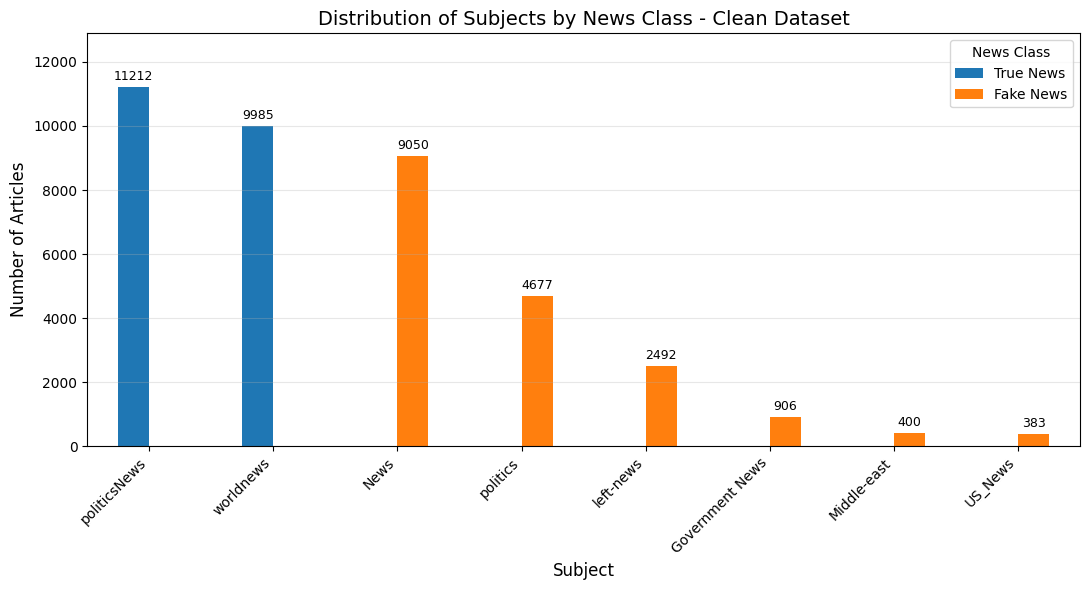

In [91]:
subject_label_counts = pd.crosstab(df_clean["subject"], df_clean["label"])

subject_label_counts = subject_label_counts.rename(
    columns={0: "True News", 1: "Fake News"}
)

subject_label_counts = subject_label_counts.loc[
    subject_label_counts.sum(axis=1).sort_values(ascending=False).index
]

ax = subject_label_counts.plot(kind="bar", figsize=(11, 6))

plt.title("Distribution of Subjects by News Class - Clean Dataset", fontsize=14)
plt.xlabel("Subject", fontsize=12)
plt.ylabel("Number of Articles", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend(title="News Class")

plt.ylim(0, subject_label_counts.values.max() * 1.15)
plt.grid(axis="y", alpha=0.3)

for container in ax.containers:
    labels = [
        f"{int(bar.get_height())}" if bar.get_height() > 0 else ""
        for bar in container
    ]
    ax.bar_label(container, labels=labels, fontsize=9, padding=3)

plt.tight_layout()
plt.show()

## Observations on the Category-by-Class Chart

The chart clearly shows that, even in the clean dataset, categories are not shared between fake news and true news.

The categories associated with fake news are represented only by the orange bar, while the categories associated with true news are represented only by the blue bar.

In particular:

- `Government News`, `Middle-east`, `News`, `US_News`, `left-news` and `politics` appear only among fake news;
- `politicsNews` and `worldnews` appear only among true news.

This separation confirms that the `subject` column is strongly connected to the news class.

To avoid the model learning a shortcut based on category, it will be preferable not to use `subject` as an input variable in the first version of the model. Instead, the model should learn from textual contents, namely `title` and `text`.


## Analysis of Title Length

In this phase, we analyze the length of news titles.

The title is an important component because it often summarizes the content of the news item and may contain useful signals for distinguishing fake news from true news.

To begin, we create a new column called `title_word_count`, which contains the number of words present in the title of each news item.


In [92]:
df_clean["title_word_count"] = df_clean["title"].str.split().str.len()

display(df_clean[["title", "label", "title_word_count"]].head())

,title,label,title_word_count
0,Ben Stein Calls Out 9th Circuit Court: Committ...,1,14
1,Trump drops Steve Bannon from National Securit...,0,8
2,Puerto Rico expects U.S. to lift Jones Act shi...,0,10
3,OOPS: Trump Just Accidentally Confirmed He Le...,1,12
4,Donald Trump heads for Scotland to reopen a go...,0,10


## Observations on Title Length

The output shows that the new column `title_word_count` was correctly added to the clean dataset.

This variable indicates the number of words present in the title of each news item.

From the first rows displayed, it can be observed that titles have different lengths, for example 14, 8, 10, 12 and 10 words. The `label` column also makes it possible to distinguish whether each title belongs to fake news or true news.

This information will be useful in the following analyses to compare the average title length of fake news with that of true news and verify whether relevant differences exist between the two classes.


## Comparison of Title Length by Class

After creating the `title_word_count` variable, we analyze title length by separating true news from fake news.

This comparison makes it possible to verify whether fake news titles tend to be longer or shorter than true news titles.

To do this, we calculate descriptive statistics for title length in each class.


In [93]:
df_clean.groupby("label")["title_word_count"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,21197.0,9.951172,1.699195,4.0,9.0,10.0,11.0,20.0
1,17908.0,14.324771,3.965755,1.0,12.0,14.0,16.0,42.0


## Observations on Title Length by Class

The descriptive statistics show a difference in title length between true news and fake news.

For true news, indicated by `label = 0`, the average title length is about **10 words**.

For fake news, indicated by `label = 1`, the average title length is instead about **14 words**.

The median also confirms this difference:

- true news: median equal to **10 words**;
- fake news: median equal to **14 words**.

This suggests that, in the analyzed dataset, fake news titles tend to be longer than true news titles.

Title length may therefore represent useful information to explore, although the main model should be based mainly on the textual content of the news items.


## Visualization of Title Length by Class

After statistically comparing title length, we represent the distribution through a boxplot.

The boxplot makes it possible to observe the median, variability and presence of extreme values in title length in a concise way.

This visualization helps us understand whether fake news and true news show clear differences in title structure.


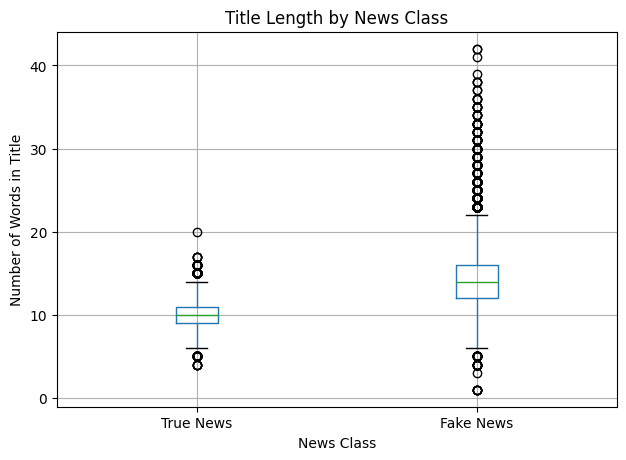

In [94]:
df_clean.boxplot(column="title_word_count", by="label", figsize=(7, 5))

plt.title("Title Length by News Class")
plt.suptitle("")
plt.xlabel("News Class")
plt.ylabel("Number of Words in Title")
plt.xticks([1, 2], ["True News", "Fake News"])
plt.show()

### Observations on the Title Length Boxplot

The boxplot shows a clear difference between the title length of true news and fake news.

True news titles are more concentrated around lower values, with a median close to **10 words**. Variability is limited and there are few extreme values.

Fake news titles, instead, show a higher median, close to **14 words**, and greater variability. There are also several extreme values, with titles exceeding **30** or even **40 words**.

This visualization confirms what was observed in the descriptive statistics: in the analyzed dataset, fake news titles tend to be longer and more variable on average than true news titles.


## Analysis of Patterns in Titles

After analyzing title length, we further examine the presence of recurring textual patterns.

This analysis is useful because fake news titles may show specific stylistic characteristics, such as more frequent use of emphatic punctuation, questions, uppercase words or recurring terms.

The objective is not yet to build the model, but to observe whether preliminary differences exist between fake news titles and true news titles.


In [95]:
def get_common_words(text_series, n=20):
    """
    Extracts the most frequent words from a series of texts.

    The function converts texts to lowercase, removes symbols and numbers,
    splits texts into individual words and returns the most recurring words.
    """
    words = []

    for text in text_series:
        text = text.lower()
        text = re.sub(r"[^a-zA-Z\s]", "", text)
        words.extend(text.split())

    return Counter(words).most_common(n)


fake_titles = df_clean[df_clean["label"] == 1]["title"]
true_titles = df_clean[df_clean["label"] == 0]["title"]

fake_common_words = get_common_words(fake_titles)
true_common_words = get_common_words(true_titles)

fake_common_words_df = pd.DataFrame(
    fake_common_words,
    columns=["Word", "Frequency"]
)

true_common_words_df = pd.DataFrame(
    true_common_words,
    columns=["Word", "Frequency"]
)

print("Most frequent words in fake news titles:")
display(fake_common_words_df)

print("\nMost frequent words in true news titles:")
display(true_common_words_df)

Most frequent words in fake news titles:


,Word,Frequency
0,to,6951
1,video,6260
2,trump,6090
3,the,4826
4,of,3647
5,for,3632
6,in,3375
7,a,2868
8,on,2673
9,and,2658



Most frequent words in true news titles:


,Word,Frequency
0,to,7716
1,trump,4687
2,in,4566
3,us,3994
4,on,3297
5,of,2988
6,says,2959
7,for,2745
8,with,1485
9,house,1431


## Observations on the Most Frequent Words in Titles

The analysis of the most frequent words in titles represents a first rough exploration of textual content.

The output shows that many of the most recurring words are very common English terms, such as `to`, `the`, `of`, `for`, `in`, `a`, `on` and `and`.

These words are called stopwords and, by themselves, do not provide particularly useful information for distinguishing fake news from true news.

For this reason, this analysis should be interpreted as a preliminary check. In the next text preprocessing phase, it will be necessary to remove stopwords so that more informative words, more closely related to the content of the news items, can emerge.


## Analysis of Informative Words in Titles

After observing that many stopwords appear among the most frequent words, we proceed with a cleaner analysis.

In this step, we remove very common English words such as `the`, `and`, `to`, `of` and `in`, because they do not provide particularly useful information about the content of the news item.

The objective is to highlight more meaningful terms in fake news and true news titles, in order to identify possible recurring topics or lexical patterns.


In [96]:
def get_informative_words(text_series, n=20):
    """
    Extracts the most frequent informative words from a series of titles.

    The function removes symbols and numbers, removes very common English words
    and returns the most frequent words with their number of occurrences.
    """
    words = []

    stopwords = set(ENGLISH_STOP_WORDS)

    for text in text_series:
        text = text.lower()
        text = re.sub(r"[^a-zA-Z\s]", " ", text)

        for word in text.split():
            if word not in stopwords and len(word) > 2:
                words.append(word)

    return Counter(words).most_common(n)


fake_informative_words = get_informative_words(fake_titles)
true_informative_words = get_informative_words(true_titles)

fake_informative_words_df = pd.DataFrame(
    fake_informative_words,
    columns=["Word", "Frequency"]
)

true_informative_words_df = pd.DataFrame(
    true_informative_words,
    columns=["Word", "Frequency"]
)

print("Most frequent informative words in fake news titles:")
display(fake_informative_words_df)

print("\nMost frequent informative words in true news titles:")
display(true_informative_words_df)

Most frequent informative words in fake news titles:


,Word,Frequency
0,trump,7780
1,video,6398
2,obama,1741
3,watch,1561
4,hillary,1543
5,just,1252
6,clinton,827
7,president,823
8,donald,748
9,gop,737



Most frequent informative words in true news titles:


,Word,Frequency
0,trump,5511
1,says,2959
2,house,1443
3,russia,965
4,north,909
5,korea,883
6,new,871
7,white,812
8,china,774
9,senate,756


## Observations on Informative Words in Titles

After stopword removal, the analysis shows more meaningful words than the previous raw title analysis.

In fake news titles, the most frequent terms are mainly `trump`, `video`, `obama`, `watch`, `hillary`, `just`, `clinton`, `president`, `donald`, `gop`, `breaking`, `tweets`, `media` and `muslim`. The presence of words such as `video`, `watch`, `breaking` and `tweets` suggests a style more oriented toward attracting the reader's attention.

In true news titles, terms such as `trump`, `says`, `house`, `russia`, `north`, `korea`, `china`, `senate`, `court`, `republican`, `tax`, `election`, `deal`, `vote` and `iran` appear instead. These words seem more connected to institutional politics, international relations, elections and government decisions.

It is important to observe that `trump` is the most frequent term in both classes. This indicates that the dataset is strongly focused on U.S. politics and that a single word, by itself, is not sufficient to distinguish a fake news item from a true news item.

Overall, this analysis highlights preliminary lexical differences between the titles of the two classes, but the results should be interpreted as descriptive of the analyzed dataset.


## Analysis of Bigrams and Trigrams in Titles

After analyzing the most informative individual words, we further examine the analysis by considering combinations of consecutive words.

In particular, we analyze:

- bigrams, that is, pairs of consecutive words;
- trigrams, that is, groups of three consecutive words.

This analysis is useful because some recurring expressions, such as `donald trump`, `hillary clinton`, `white house` or `north korea`, can be more informative than individual words considered separately.

The objective is to identify possible recurring expressions in fake news and true news titles.


In [97]:
def get_top_ngrams(text_series, ngram_range=(2, 3), n=20):
    """
    Extracts the most frequent bigrams and trigrams from a series of texts.

    The function removes the most common English words, counts the combinations
    of two or three consecutive words and returns the most frequent ones.
    """
    vectorizer = CountVectorizer(
        stop_words="english",
        ngram_range=ngram_range,
        min_df=2
    )

    ngram_matrix = vectorizer.fit_transform(text_series)
    ngram_counts = ngram_matrix.sum(axis=0).A1

    ngram_df = pd.DataFrame({
        "ngram": vectorizer.get_feature_names_out(),
        "count": ngram_counts
    })

    return ngram_df.sort_values(by="count", ascending=False).head(n).reset_index(drop=True)


fake_title_ngrams = get_top_ngrams(fake_titles)
true_title_ngrams = get_top_ngrams(true_titles)

print("Most frequent bigrams and trigrams in fake news titles:")
display(fake_title_ngrams)

print("\nMost frequent bigrams and trigrams in true news titles:")
display(true_title_ngrams)


Most frequent bigrams and trigrams in fake news titles:


,ngram,count
0,donald trump,710
1,hillary clinton,317
2,president trump,306
3,fox news,273
4,white house,267
5,trump video,233
6,ted cruz,213
7,trump just,201
8,bernie sanders,194
9,trump supporter,169



Most frequent bigrams and trigrams in true news titles:


,ngram,count
0,white house,785
1,north korea,709
2,trump says,362
3,islamic state,248
4,supreme court,232
5,puerto rico,178
6,south korea,156
7,travel ban,154
8,says trump,150
9,trump administration,148


## Observations on Bigrams and Trigrams in Titles

The analysis of bigrams and trigrams makes it possible to observe recurring expressions in titles, going beyond a simple count of individual words.

In fake news titles, expressions mainly related to U.S. politics and political figures that are very present in the dataset emerge, such as `donald trump`, `hillary clinton`, `president trump`, `ted cruz`, `bernie sanders`, `president obama` and `paul ryan`.

There are also combinations that suggest a style more oriented toward grabbing the reader's attention or polarization, such as `trump video`, `trump just`, `trump supporter`, `anti trump`, `watch trump`, `fake news`, `year old` and `lives matter`.

In true news titles, expressions more connected to institutions, international politics and government decisions emerge instead, such as `white house`, `north korea`, `islamic state`, `supreme court`, `puerto rico`, `south korea`, `travel ban`, `trump administration`, `house speaker`, `nuclear deal`, `russia probe`, `foreign minister`, `attorney general` and `saudi arabia`.

This analysis shows that fake and true titles share some political themes, but represent them with different nuances. Fake news appears more focused on political figures, polarizing formulas and attention-grabbing expressions, while true news more often shows expressions related to institutions, countries, geopolitical events and official processes.

Overall, bigrams and trigrams help identify lexical patterns that are more informative than individual words and better address the project question about recurring topics and patterns in titles.


## Analysis of Stylistic Patterns in Titles

After analyzing the most frequent and informative words, we further examine some stylistic elements present in titles.

In particular, we check whether fake news and true news titles differ in terms of:

- presence of exclamation marks;
- presence of question marks;
- number of words written entirely in uppercase.

These elements may be useful because fake news titles may use a more emphatic, sensationalistic or attention-grabbing style more often.


In [98]:
df_clean["title_has_exclamation"] = df_clean["title"].str.contains("!", regex=False)
df_clean["title_has_question"] = df_clean["title"].str.contains("?", regex=False)
df_clean["title_uppercase_words"] = df_clean["title"].apply(
    lambda title: sum(1 for word in title.split() if word.isupper() and len(word) > 1)
)

title_punctuation_patterns = df_clean.groupby("label")[[
    "title_has_exclamation",
    "title_has_question"
]].mean() * 100

title_uppercase_patterns = df_clean.groupby("label")[[
    "title_uppercase_words"
]].mean()

print("Percentage of titles with exclamation/question marks by class:")
display(title_punctuation_patterns)

print("\nAverage number of uppercase words in titles by class:")
display(title_uppercase_patterns)

Percentage of titles with exclamation/question marks by class:


,title_has_exclamation,title_has_question
label,,
0,0.084918,0.641600
1,11.877373,5.762788



Average number of uppercase words in titles by class:


,title_uppercase_words
label,
0,0.383828
1,2.757929


## Observations on Patterns in Titles

The analysis shows some stylistic differences between true news titles and fake news titles.

Fake news titles show a greater presence of exclamation marks: about **11.88%** of fake titles contain at least one exclamation mark, compared with about **0.08%** of true titles.

Question marks are also more frequent in fake titles: about **5.76%** of fake titles contain at least one question mark, compared with about **0.64%** of true titles.

In addition, fake titles contain on average about **2.76 words** written entirely in uppercase, while true titles contain on average about **0.38**.

These results indicate that fake news titles tend to have a more emphatic and sensationalistic style, characterized by greater use of expressive punctuation and uppercase words.


## Analysis of Text Length

After analyzing title length, we move on to the length of the textual content of the news items.

The news text is one of the main sources of information for the Natural Language Processing model, because it contains the full content of the article.

For this analysis, we create a new column called `text_word_count`, which indicates the number of words present in the body of the news item.


In [99]:
df_clean["text_word_count"] = df_clean["text"].str.split().str.len()

display(df_clean[["text", "label", "text_word_count"]].head())

,text,label,text_word_count
0,"21st Century Wire says Ben Stein, reputable pr...",1,171
1,WASHINGTON (Reuters) - U.S. President Donald T...,0,771
2,(Reuters) - Puerto Rico Governor Ricardo Rosse...,0,304
3,"On Monday, Donald Trump once again embarrassed...",1,183
4,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",0,529


### Observations on Text Length

The output shows that the new column `text_word_count` was correctly added.

This variable indicates the number of words present in the textual body of each news item.

From the first rows displayed, it can be observed that texts have different lengths, for example 171, 771, 304, 183 and 529 words. The `label` column also makes it possible to distinguish whether each text belongs to fake news or true news.

This information will be useful in the following analyses to compare the average text length of fake news with that of true news and verify whether relevant differences exist between the two classes.


## Comparison of Text Length by Class

After creating the `text_word_count` variable, we analyze text length by separating true news from fake news.

This comparison makes it possible to verify whether the body of fake news tends to be longer or shorter than the body of true news.

To do this, we calculate descriptive statistics for text length in each class.


In [100]:
df_clean.groupby("label")["text_word_count"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,21197.0,384.863471,273.831833,0.0,147.0,359.0,523.0,5172.0
1,17908.0,414.690306,356.987012,0.0,264.0,371.0,499.0,8135.0


## Observations on Text Length by Class

The descriptive statistics show that the average text length is slightly higher in fake news than in true news.

For true news, indicated by `label = 0`, the average text length is about **385 words**.

For fake news, indicated by `label = 1`, the average text length is instead about **415 words**.

The median, however, is fairly similar between the two classes:

- true news: median equal to **359 words**;
- fake news: median equal to **371 words**.

This means that, although fake news has a higher average, the central difference between the two distributions is not very marked.

It can also be observed that both classes contain texts with length equal to `0`, confirming the presence of empty texts already identified earlier.


## Visualization of Text Length by Class

After statistically comparing text length, we represent the distribution through a boxplot.

This visualization makes it possible to observe whether the body of fake news and true news shows clear differences in length.

The boxplot also makes it possible to identify the presence of very short texts, empty texts and particularly long articles.


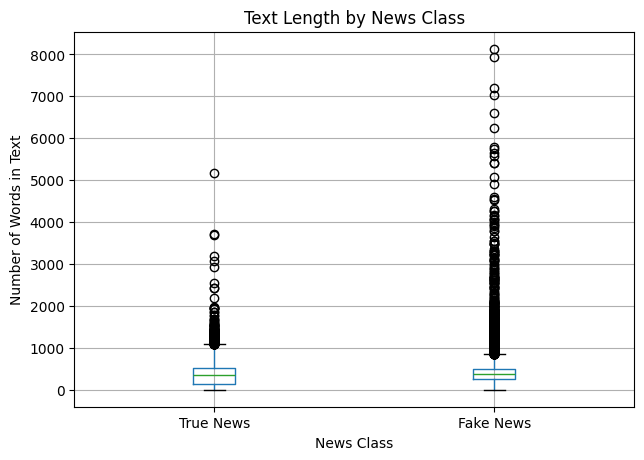

In [101]:
df_clean.boxplot(column="text_word_count", by="label", figsize=(7, 5))

plt.title("Text Length by News Class")
plt.suptitle("")
plt.xlabel("News Class")
plt.ylabel("Number of Words in Text")
plt.xticks([1, 2], ["True News", "Fake News"])
plt.show()

### Observations on the Text Length Boxplot

The boxplot shows that the distribution of text length is similar between true news and fake news in the central part.

The medians of the two classes are in fact close, confirming what was observed in the descriptive statistics.

However, the chart also highlights the presence of many extreme values, that is, articles much longer than most observations.

These extreme values are present in both classes, but they are particularly numerous and higher among fake news, where some texts exceed even **8,000 words**.

This suggests that text length alone does not seem to clearly distinguish the two classes, but it can still provide useful information during exploratory analysis.


## Creation of the Combined Text Variable

After analyzing title and text separately, a new variable called `content` is created.

This column combines the information present in:

- `title`;
- `text`.

The objective is to obtain a single textual field that represents the entire news item and can be used in the following text cleaning and NLP modeling phases.

This choice is important because the model will be able to use both the title and the body of the news item. In addition, observations with empty `text` are not automatically excluded, because the title remains available and may contain useful information for classification.


In [102]:
df_clean["content"] = (
    df_clean["title"].fillna("").str.strip()
    + " "
    + df_clean["text"].fillna("").str.strip()
).str.strip()

display(df_clean[["title", "text", "content", "label"]].head())

,title,text,content,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",Ben Stein Calls Out 9th Circuit Court: Committ...,1
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,Trump drops Steve Bannon from National Securit...,0
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,Puerto Rico expects U.S. to lift Jones Act shi...,0
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",OOPS: Trump Just Accidentally Confirmed He Lea...,1
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",Donald Trump heads for Scotland to reopen a go...,0


### Observations on the `content` Variable

The output shows that the new `content` column was correctly added to the DataFrame.

This variable contains the union of the title and the body of the news item, creating a single, more complete textual field.

The presence of `content` will be useful in the following phases because it will make it possible to apply text cleaning and NLP vectorization operations on a single column, instead of managing `title` and `text` separately.

This choice is also especially useful considering that some texts are empty, while titles are always present and can therefore still provide textual information to the model.

It is important to specify that, at this stage, `content` is still a raw textual variable. It may still contain Reuters source references, URLs, HTML elements or shortcodes, punctuation, uppercase letters and other elements that have not yet been normalized.

For this reason, before modeling, the `content` column will need to undergo a text preprocessing phase. In particular, it will be necessary to evaluate the removal or normalization of URLs, explicit source references, technical elements and low-information words, in order to reduce the risk that the model learns shortcuts related to the dataset structure instead of the real content of the news items.


## Final Check of the DataFrame Structure

After adding the target variable and some new columns useful for textual analysis, we check the updated structure of the DataFrame.

This step makes it possible to verify:

- the total number of rows and columns;
- the names of the available columns;
- the data type associated with each variable.

This final check is useful before moving on to the next data cleaning and preparation operations.


In [103]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39105 entries, 0 to 39104
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   title                  39105 non-null  object        
 1   text                   39105 non-null  object        
 2   subject                39105 non-null  object        
 3   date                   39105 non-null  object        
 4   label                  39105 non-null  int64         
 5   date_clean             39099 non-null  datetime64[ns]
 6   contains_reuters       39105 non-null  bool          
 7   title_word_count       39105 non-null  int64         
 8   title_has_exclamation  39105 non-null  bool          
 9   title_has_question     39105 non-null  bool          
 10  title_uppercase_words  39105 non-null  int64         
 11  text_word_count        39105 non-null  int64         
 12  content                39105 non-null  object        
dtypes

## Observations on the Final DataFrame Structure

The output of `df_clean.info()` shows that the DataFrame contains **39,105 rows and 13 columns**.

The available columns are:

- `title`: title of the news item;
- `text`: textual body of the news item;
- `subject`: news category;
- `date`: original publication date;
- `label`: target variable, where `1` indicates fake news and `0` indicates true news;
- `date_clean`: converted version of the `date` column in time format;
- `contains_reuters`: boolean variable indicating whether the text contains the Reuters source reference;
- `title_word_count`: number of words in the title;
- `title_has_exclamation`: boolean variable indicating whether the title contains at least one exclamation mark;
- `title_has_question`: boolean variable indicating whether the title contains at least one question mark;
- `title_uppercase_words`: number of words written entirely in uppercase in the title;
- `text_word_count`: number of words in the text;
- `content`: combined textual variable composed of title and text.

Most columns contain **39,105 non-null values**. The `date_clean` column instead contains **39,099 non-null values**, because **6 non-convertible dates** were identified.

The data types are consistent with the information contained in the dataset: textual columns are of type `object`, the `label` variable and the word count columns are numeric, the `contains_reuters`, `title_has_exclamation` and `title_has_question` variables are boolean, while `date_clean` is in time format.

This final check confirms that the clean DataFrame is correctly structured and that useful variables have been added for the following text cleaning, preprocessing and modeling phases.


## Conclusions of the First Analysis Phase

In this first phase, an initial exploratory analysis was carried out on the datasets containing true and fake news.

The two original datasets were loaded:

- `Fake.csv`, containing fake news;
- `True.csv`, containing true news.

The target variable `label` was then added, using the following encoding:

- `1` for fake news;
- `0` for true news.

The two datasets were then merged into a single DataFrame initially composed of **44,898 observations**. After merging, the dataset was randomly shuffled to prevent the original order of the rows, first fake news and then true news, from influencing the following analysis and modeling phases.

The initial analysis of class distribution showed that the original dataset was fairly balanced, with **23,481 fake news**, equal to about **52.30%** of the dataset, and **21,417 true news**, equal to about **47.70%**.

Data quality checks were also performed. There are no explicit missing values, but empty texts were identified in the `text` column. This aspect will need to be considered during preprocessing because the model could indirectly learn a shortcut related to the absence of text. Titles, on the other hand, are always present, suggesting that the `title` column can provide useful information even when the news body is absent.

The duplicate analysis highlighted the presence of **209 fully duplicate rows** and **5,793 duplicates considering only `title` and `text`**. Since, in an NLP project, two rows with the same title and the same text represent the same information content, a clean version of the dataset called `df_clean` was created by removing textual duplicates.

After this operation, the clean dataset contains **39,105 observations**. The class distribution remains fairly balanced, although with a slight prevalence of true news: **21,197 true news**, equal to about **54.21%**, and **17,908 fake news**, equal to about **45.79%**. Duplicate removal therefore mainly affected the fake news class.

It was also verified that there are no textual duplicates with conflicting labels, so no cases emerge where the same content was classified both as fake news and as true news.

After removing textual duplicates, the clean dataset still contains **447 empty texts** in the `text` column, of which **446** belong to class `1`, that is fake news, and **1** belongs to class `0`, that is true news. This confirms that the empty text problem remains concentrated almost exclusively in the fake news class.

The analysis of the `date` column showed that the dataset covers a period between **March 31, 2015** and **February 19, 2018**. In the clean dataset, **6 non-convertible dates** were identified, corresponding to anomalous values such as URLs, image references or portions of text. The visualization of the complete rows showed that, in some cases, the anomaly does not concern only the `date` column but also other textual columns such as `title` and `text`. Since the project is mainly oriented toward classification through NLP techniques, the `date` column is kept mostly for exploratory purposes.

A broader check was also carried out on dirty or low-information rows. In the clean dataset, **2,767 rows** were identified with at least one possible quality issue, including **2,590 rows** containing URLs, **174 very short texts**, **69 rows** with HTML elements or shortcodes and **53 rows** composed only of links. These problems are mainly concentrated in the fake news class. This aspect will need to be handled during preprocessing because the model could learn shortcuts related to URLs or technical contents instead of focusing on the informative content of the news items.

The presence of the `Reuters` source inside texts was also analyzed. In the clean dataset, **21,379 news items** contain the word `Reuters`, and this presence is strongly associated with true news. This element may represent a possible **source bias or dataset bias**, because the model could learn a shortcut based on the presence of the source instead of truly distinguishing the linguistic patterns of fake news and true news.

The analysis of the `subject` column showed that categories are not distributed across both classes. Some categories appear only among fake news, while others appear only among true news. For this reason, in the first version of the model it will be preferable not to use `subject` as an input variable, avoiding the classifier learning a shortcut based on category rather than textual content.

The title analysis showed that fake news tends to have longer titles on average than true news. Some recurring stylistic patterns were also analyzed: fake titles more frequently contain exclamation marks, question marks and words written entirely in uppercase. This suggests a more emphatic and sensationalistic style than true news.

The lexical analysis of titles was deepened by removing stopwords, so that more informative words could be observed compared with the simple raw count. In fake news titles, terms such as `video`, `watch`, `breaking`, `tweets`, `media` and references to political figures emerge, while in true news titles terms connected to institutions, international politics and government processes appear more often, such as `russia`, `north korea`, `senate`, `court`, `tax`, `vote` and `iran`.

Bigrams and trigrams, that is, combinations of two or three consecutive words, were also analyzed. This analysis made it possible to identify recurring expressions such as `donald trump`, `hillary clinton`, `president trump`, `white house`, `north korea`, `supreme court` and `russia probe`. The results show that fake and true titles share some political themes, but present different nuances: fake news seems more oriented toward political figures and polarizing formulas, while true news more often shows references to institutions, countries and geopolitical events.

The analysis of text length showed that fake news has a slightly higher average length than true news, although the medians of the two classes are fairly close. Extreme values are also present, especially in the fake news class, with some very long texts.

Finally, some new variables useful for the analysis and for later project phases were created:

- `date_clean`, converted version of the `date` column in time format;
- `contains_reuters`, boolean variable indicating whether the text contains the Reuters source reference;
- `title_word_count`, measuring the number of words in the title;
- `title_has_exclamation`, boolean variable indicating whether the title contains at least one exclamation mark;
- `title_has_question`, boolean variable indicating whether the title contains at least one question mark;
- `title_uppercase_words`, measuring the number of words written entirely in uppercase in the title;
- `text_word_count`, measuring the number of words in the text;
- `content`, combining title and text into a single textual field.

The `content` variable will be especially useful in the next phase because it will make it possible to work on a single textual field composed of title and news body. However, this variable is still raw and will need to be cleaned before modeling by removing or normalizing elements such as URLs, Reuters source references, HTML, shortcodes, non-useful punctuation and other technical signals from the dataset.

In the next phase, the work will continue with text cleaning and preprocessing, removal of explicit Reuters source references and other possible biases, creation of a stratified split between training set and test set, text transformation through TF-IDF and training of a first baseline model, for example Logistic Regression or Linear SVM.

This first phase therefore made it possible to understand the dataset structure, identify important issues for modeling and prepare a more solid basis for the next phase of cleaning, text preprocessing and NLP model training.


# Second Phase: Text Cleaning and Preprocessing

In this second phase, the work focuses on preparing the textual variable `content`, created in the previous phase by combining the title and the body of the news item.

This phase does not yet aim to train the Machine Learning model. Its purpose is to prepare the textual data for the next NLP modeling phase, where text vectorization, model training and performance evaluation will be applied.

The main objective is to transform raw text into a cleaner, more consistent version suitable for automatic analysis, while reducing the risk that the model learns shortcuts related to dataset structure rather than the real content of the news items.

During the first phase, several important issues were identified, including:

- presence of URLs and links inside texts;
- recurring references to the `Reuters` source;
- HTML elements or shortcodes;
- very short or low-information texts;
- possible technical signals from the dataset that could create bias in the model.

For this reason, targeted text cleaning operations will be applied in this phase, while avoiding the removal of potentially useful information, such as the stylistic patterns identified in titles.

The `content` variable is still raw text. After cleaning, a new column called `clean_content` will be created and used in the following vectorization and model training phases.


## Starting Dataset for Preprocessing

The second phase starts from the DataFrame `df_clean`, created in the previous phase after removing textual duplicates based on the `title` and `text` columns.

This choice allows the work to continue on a cleaner version of the dataset than the original one, avoiding identical contents being repeated multiple times during the following preprocessing and modeling phases.

The starting dataset contains **39,105 observations** and maintains a class distribution that is still fairly balanced:

- **21,197 true news**, equal to about **54.21%** of the dataset;
- **17,908 fake news**, equal to about **45.79%** of the dataset.

From this point onward, all text cleaning operations will be applied to `df_clean`.


In [104]:
print("Starting dataset dimensions for preprocessing:")
print(df_clean.shape)

class_distribution_preprocessing = pd.DataFrame({
    "News class": ["True News", "Fake News"],
    "Number of articles": df_clean["label"].value_counts().sort_index().values,
    "Percentage": (
        df_clean["label"].value_counts(normalize=True).sort_index().values * 100
    )
})

print("\nClass distribution:")
display(class_distribution_preprocessing.round(2))


Starting dataset dimensions for preprocessing:
(39105, 13)

Class distribution:


,News class,Number of articles,Percentage
0,True News,21197,54.21
1,Fake News,17908,45.79


## Check of Empty Texts before Preprocessing

During the first phase, it emerged that some observations have an empty `text` column, although a title is available.

Since the `content` variable is created by combining `title` and `text`, these rows are not necessarily unusable: even without the body of the news item, the title may contain relevant information for the model.

For this reason, rows with empty `text` will not be automatically removed in this phase. They will instead be checked and kept, unless the final textual variable `clean_content` is also empty after cleaning.

This choice makes it possible not to remove potentially informative observations and to avoid a loss concentrated mainly in the fake news class.


In [105]:
empty_text_before_preprocessing = df_clean["text"].fillna("").str.strip().eq("").sum()

empty_text_by_class = (
    df_clean[df_clean["text"].fillna("").str.strip().eq("")]
    .groupby("label")
    .size()
    .reindex([0, 1], fill_value=0)
)

empty_text_summary = pd.DataFrame({
    "News class": ["True News", "Fake News"],
    "Empty text rows": empty_text_by_class.values
})

class_distribution_after_check = pd.DataFrame({
    "News class": ["True News", "Fake News"],
    "Number of articles": df_clean["label"].value_counts().sort_index().values,
    "Percentage": (
        df_clean["label"].value_counts(normalize=True).sort_index().values * 100
    )
})

print("Number of rows with empty text before preprocessing:")
print(empty_text_before_preprocessing)

print("\nClass distribution of rows with empty text:")
display(empty_text_summary)

print("\nDataset dimensions after the check:")
print(df_clean.shape)

print("\nClass distribution after the check:")
display(class_distribution_after_check.round(2))


Number of rows with empty text before preprocessing:
447

Class distribution of rows with empty text:


,News class,Empty text rows
0,True News,1
1,Fake News,446



Dataset dimensions after the check:
(39105, 13)

Class distribution after the check:


,News class,Number of articles,Percentage
0,True News,21197,54.21
1,Fake News,17908,45.79


### Observations on the Results

The check shows that, before preprocessing, there are **447 observations** with an empty `text` column.

The distribution by class shows that the problem is almost entirely concentrated in the fake news class: **446 observations** belong to class `1`, while only **1 observation** belongs to class `0`.

These rows are not removed in this phase because they still have an available title. Since the `content` variable is built by combining `title` and `text`, observations with an empty text body can still preserve useful information through the title.

After this check, the dataset remains composed of **39,105 observations** and **13 columns**.

The class distribution remains unchanged: true news items are **21,197**, equal to **54.21%** of the dataset, while fake news items are **17,908**, equal to **45.79%**.

Rows will be removed only in a later phase if, after text cleaning, the `clean_content` variable is also empty.


## Definition of the Text Cleaning Function

In this phase, a function dedicated to cleaning the textual variable `content` is defined.

The objective is to prepare the text for the following Natural Language Processing phases, removing technical elements or elements strongly connected to the dataset structure, without aggressively removing information that may be useful for the model.

In particular, the function will be used to:

- convert text to lowercase;
- remove URLs and links;
- remove recurring Reuters source references and associated journalistic datelines;
- remove possible HTML elements;
- remove technical shortcodes such as `[vc_row]`, `[vc_column]` or `[td_block]`;
- remove editorial markers related to images, such as `featured image`, `image via`, `photo by`, `photo via` and `getty images`;
- normalize multiple spaces.

At this stage, numbers, punctuation or other potentially informative textual patterns are not removed in a general way. The removal of image markers was introduced conservatively because these elements describe the editorial structure of the articles more than the informative content of the news item.

Some stylistic signals identified in the first phase, such as exclamation marks, question marks and uppercase words in titles, will be preserved in dedicated variables or considered during the modeling phase.

The function is only defined in this cell. Its application to the dataset will be performed in a later step.


In [106]:
def clean_text(text):
    """
    Cleans the raw news content by removing technical elements,
    Reuters source references, journalistic datelines, URLs, HTML,
    shortcodes, image-related editorial markers and extra spaces,
    without aggressively removing numbers or punctuation
    that may be informative.
    """
    text = str(text)

    # Remove typical Reuters datelines, for example:
    # WASHINGTON (Reuters) -
    # LONDON (Reuters) -
    # SEATTLE/WASHINGTON (Reuters) -
    text = re.sub(
        r"\b[A-Z][A-Z./&' -]{1,100}(?:,\s*[A-Za-z .'-]{2,80})?\s+\(Reuters\)\s*-\s*",
        " ",
        text
    )

    # Remove cases without an explicit location, for example:
    # (Reuters) -
    text = re.sub(r"\(Reuters\)\s*-\s*", " ", text)

    # Remove URLs and links.
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)

    # Remove HTML elements.
    text = re.sub(r"<[^>]+>", " ", text)

    # Remove technical shortcodes, for example [vc_row], [vc_column], [td_block].
    text = re.sub(r"\[(?:/?vc_[^\]]*|/?td_[^\]]*)\]", " ", text)

    # Remove recurring editorial markers and image credits.
    # The removal is conservative: it removes phrases such as "featured image",
    # "photo by", "image via" and "getty images", but it does not remove the generic word
    # "image" when it appears on its own.
    text = re.sub(
        r"\bfeatured\s+image\b[:\s-]*[^.!?\n]{0,200}",
        " ",
        text,
        flags=re.IGNORECASE
    )

    text = re.sub(
        r"\bimage\s+via\b[:\s-]*[^.!?\n]{0,200}",
        " ",
        text,
        flags=re.IGNORECASE
    )

    text = re.sub(
        r"\bphoto\s+by\b[:\s-]*[^.!?\n]{0,200}",
        " ",
        text,
        flags=re.IGNORECASE
    )

    text = re.sub(
        r"\bphoto\s+via\b[:\s-]*[^.!?\n]{0,200}",
        " ",
        text,
        flags=re.IGNORECASE
    )

    text = re.sub(
        r"\bgetty\s+images?\b",
        " ",
        text,
        flags=re.IGNORECASE
    )

    # Convert to lowercase and remove remaining Reuters references.
    text = text.lower()
    text = re.sub(r"\breuters\b", " ", text)

    # Normalize multiple spaces.
    text = re.sub(r"\s+", " ", text).strip()

    return text


## Application of the Cleaning Function

After defining the `clean_text` function, the next step consists of applying it to the `content` column.

This operation makes it possible to create a new variable called `clean_content`, which contains a cleaner version of the original text.

The `content` column is kept in the dataset because it represents the raw text, while `clean_content` will be used in the following NLP preprocessing and modeling phases.


In [107]:
clean_text_source = code_source(clean_text)
df_clean["clean_content"] = cached_clean_content(df_clean["content"], clean_text_source)

display(df_clean[["content", "clean_content"]].head())

,content,clean_content
0,Ben Stein Calls Out 9th Circuit Court: Committ...,ben stein calls out 9th circuit court: committ...
1,Trump drops Steve Bannon from National Securit...,trump drops steve bannon from national securit...
2,Puerto Rico expects U.S. to lift Jones Act shi...,puerto rico expects u.s. to lift jones act shi...
3,OOPS: Trump Just Accidentally Confirmed He Lea...,oops: trump just accidentally confirmed he lea...
4,Donald Trump heads for Scotland to reopen a go...,donald trump heads for scotland to reopen a go...


In [108]:
# Check of Reuters reference removal from the cleaned text

print("Number of cleaned texts that still contain the word 'reuters':")
print(df_clean["clean_content"].str.contains(r"\breuters\b", regex=True, na=False).sum())

reuters_dateline_check = df_clean[
    df_clean["content"].str.contains(r"\(Reuters\)", regex=True, na=False)
][["content", "clean_content", "label"]].head(10)

display(reuters_dateline_check)


Number of cleaned texts that still contain the word 'reuters':
0


,content,clean_content,label
1,Trump drops Steve Bannon from National Securit...,trump drops steve bannon from national securit...,0
2,Puerto Rico expects U.S. to lift Jones Act shi...,puerto rico expects u.s. to lift jones act shi...,0
4,Donald Trump heads for Scotland to reopen a go...,donald trump heads for scotland to reopen a go...,0
8,North Korea shows no sign it is serious about ...,north korea shows no sign it is serious about ...,0
9,Trump signals willingness to raise U.S. minimu...,trump signals willingness to raise u.s. minimu...,0
10,New Jersey's Christie mulls run to lead Republ...,new jersey's christie mulls run to lead republ...,0
12,"France, Germany want Iran to reverse ballistic...","france, germany want iran to reverse ballistic...",0
13,Aide to EU Commission head tweets picture of w...,aide to eu commission head tweets picture of w...,0
15,U.S. gives Laos extra $90 million to help clea...,u.s. gives laos extra $90 million to help clea...,0
19,U.S. House panel offers alternative to retirem...,u.s. house panel offers alternative to retirem...,0


### Observations on the Results

The application of the `clean_text` function correctly created the new `clean_content` column.

By comparing `content` and `clean_content`, it can be observed that the original text was transformed into a cleaner and more uniform version. In particular, the text was converted to lowercase and technical or potentially distorting elements were removed, such as URLs, links, Reuters source references, journalistic datelines, HTML elements, shortcodes and editorial markers related to images.

The `content` column is kept as a reference to the original text, while `clean_content` represents the preprocessed version that will be used in the following NLP analysis and model training phases.

It is important to specify that, in this version of the cleaning process, numbers, punctuation and other potentially informative textual patterns are not removed in a general way. This choice makes it possible to preserve signals that may be useful during modeling.

The removal of editorial markers related to images was introduced to reduce the risk that the model learns shortcuts related to article structure, such as photo credits or technical references, instead of focusing on the textual content of the news item.

A specific check was also added to verify that the word `reuters` is no longer present in the `clean_content` column after cleaning.


## Check of Empty Texts after Cleaning

After applying the `clean_text` function, it is important to check whether some rows have empty textual content in the `clean_content` column.

This check is necessary because some news items may contain almost exclusively technical or low-information elements removed during cleaning, such as URLs, source references, HTML, shortcodes or journalistic datelines.

Rows with empty `clean_content` may not be useful for model training because they would not provide meaningful textual information.


In [109]:
empty_clean_content = (df_clean["clean_content"].str.strip() == "").sum()

print("Number of empty clean_content values:", empty_clean_content)

Number of empty clean_content values: 5


### Observations on the Results

The check shows that, after applying the `clean_text` function, there are `5` rows with an empty value in the `clean_content` column.

This result indicates that some observations were composed almost exclusively of technical or low-information elements, such as URLs, source references, HTML or shortcodes. After removing these elements, those rows no longer preserve useful textual content for modeling.

Since the number of empty rows is very limited compared with the overall size of the dataset, these observations can be removed without significantly altering the data distribution. This step avoids training the model on texts without useful content.


## Removal of Empty Texts after Cleaning

After checking for some rows with empty `clean_content`, the next step consists of removing them.

These observations do not provide useful textual information for the model, because their content became empty after the cleaning operations.

Since they represent a very small number of rows compared with the overall size of the dataset, their removal does not significantly alter the data structure.


In [110]:
df_clean = df_clean[df_clean["clean_content"].str.strip() != ""].reset_index(drop=True)

print("Dataset shape after removing empty clean_content rows:", df_clean.shape)

Dataset shape after removing empty clean_content rows: (39100, 14)


### Observations on the Results

After removing the rows with empty `clean_content`, the dataset contains `39100` observations and `14` columns.

The reduction in the number of rows is minimal, since only observations that did not preserve any useful textual content after cleaning were removed.

This operation makes the dataset more suitable for the following modeling phase, avoiding model training on empty texts or texts without meaningful information.


## Check of Class Distribution after Cleaning

After removing rows with empty `clean_content`, it is useful to check the distribution of the target variable `label` again.

This check makes sure that the cleaning process did not significantly modify the balance between fake news and true news.

Maintaining a consistent class distribution is important for the following model training and evaluation phase.


In [111]:
class_distribution_after_cleaning = df_clean["label"].value_counts().sort_index()
class_percentage_after_cleaning = df_clean["label"].value_counts(normalize=True).sort_index() * 100

class_summary_after_cleaning = pd.DataFrame({
    "News class": ["True News", "Fake News"],
    "Number of articles": class_distribution_after_cleaning.values,
    "Percentage": class_percentage_after_cleaning.values
})

display(class_summary_after_cleaning.round(2))

,News class,Number of articles,Percentage
0,True News,21197,54.21
1,Fake News,17903,45.79


### Observations on the Results

After cleaning and removing rows with empty `clean_content`, the distribution of the target variable `label` remains fairly balanced.

True news represents `54.21%` of the dataset, while fake news represents `45.79%`.

This result confirms that the cleaning operations did not significantly alter the class composition. The dataset therefore remains suitable for the following model training phase, without presenting a strong imbalance between true and fake news.


## Creation of the Final Datasets for Modeling

After completing text cleaning, two versions of the final dataset are created for the following modeling phase.

The first version, `df_model_text`, contains only:

- `clean_content`, which represents the preprocessed text of the news item;
- `label`, which represents the target variable to predict.

This version will make it possible to build a first baseline model based exclusively on textual content.

The second version, `df_model_features`, keeps `clean_content` and `label`, but also adds some stylistic features identified during the exploratory analysis, such as title length, the presence of exclamation or question marks, the number of uppercase words in the title and text length.

This second version will make it possible to verify whether the stylistic patterns observed in the first phase improve performance compared with the text-only model.

In both datasets, potentially problematic columns such as `subject`, `date`, `title` and `text` are not used directly. The `subject` column, in particular, is excluded to avoid the model learning a shortcut based on category instead of news content.


In [112]:
# Baseline dataset: uses only the cleaned text
df_model_text = df_clean[["clean_content", "label"]].copy()

display(df_model_text.head())
print("Text-only modeling dataset shape:", df_model_text.shape)

# Complete dataset: uses cleaned text and stylistic features identified in the exploratory analysis
df_model_features = df_clean[
    [
        "clean_content",
        "title_word_count",
        "title_has_exclamation",
        "title_has_question",
        "title_uppercase_words",
        "text_word_count",
        "label"
    ]
].copy()

display(df_model_features.head())
print("Text + stylistic features modeling dataset shape:", df_model_features.shape)


,clean_content,label
0,ben stein calls out 9th circuit court: committ...,1
1,trump drops steve bannon from national securit...,0
2,puerto rico expects u.s. to lift jones act shi...,0
3,oops: trump just accidentally confirmed he lea...,1
4,donald trump heads for scotland to reopen a go...,0


Text-only modeling dataset shape: (39100, 2)


,clean_content,title_word_count,title_has_exclamation,title_has_question,title_uppercase_words,text_word_count,label
0,ben stein calls out 9th circuit court: committ...,14,False,False,0,171,1
1,trump drops steve bannon from national securit...,8,False,False,0,771,0
2,puerto rico expects u.s. to lift jones act shi...,10,False,False,1,304,0
3,oops: trump just accidentally confirmed he lea...,12,False,False,2,183,1
4,donald trump heads for scotland to reopen a go...,10,False,False,0,529,0


Text + stylistic features modeling dataset shape: (39100, 7)


### Observations on the Results

Two versions of the final dataset for modeling were created.

The first version, `df_model_text`, contains **39,100 observations** and **2 columns**:

- `clean_content`, which represents the clean text of the news item;
- `label`, which represents the class to predict.

This version will be useful to build a first baseline model based exclusively on textual content.

The second version, `df_model_features`, contains **39,100 observations** and **7 columns**. In addition to `clean_content` and `label`, it includes some stylistic features identified during the exploratory analysis:

- `title_word_count`;
- `title_has_exclamation`;
- `title_has_question`;
- `title_uppercase_words`;
- `text_word_count`.

This second version will make it possible to evaluate whether adding stylistic patterns from titles and text length improves model performance compared with the text-only baseline.

In both cases, potentially problematic columns such as `subject`, `date`, `title` and `text` are not used directly as model features. The `subject` column, in particular, is excluded to prevent the classifier from learning a shortcut based on category instead of news content.

The dataset is therefore ready for the next phase, dedicated to data splitting and construction of the classification model.


## Conclusions of the Second Phase

In this second phase, the textual variable to be used in the following NLP modeling phase was prepared.

The work started from the DataFrame `df_clean`, obtained in the first phase after removing textual duplicates. The starting dataset contained **39,105 observations** and maintained a fairly balanced class distribution.

Observations with empty `text` were not automatically removed because titles were still available and could provide useful information for classification. The `content` variable, built by combining `title` and `text`, therefore made it possible to preserve this information as well.

The `clean_text` function was then defined and applied with the objective of removing technical or potentially distorting elements, such as URLs, Reuters source references, journalistic datelines, HTML, shortcodes and editorial markers related to images. The cleaning process did not aggressively remove numbers, punctuation or other potentially informative textual patterns.

The removal of editorial markers related to images was introduced to reduce the risk that the model learns signals specific to article structure, such as photo credits or technical references, instead of focusing on the textual content of the news item.

After cleaning, only **5 observations** with empty `clean_content` were identified and removed. The final dataset therefore contains **39,100 observations**, with a class distribution that is still balanced: **21,197 true news** and **17,903 fake news**.

At the end of the phase, two versions of the dataset were created for modeling:

- `df_model_text`, containing only `clean_content` and `label`, useful for building a first baseline model based exclusively on text;
- `df_model_features`, also containing some stylistic features identified during exploratory analysis, useful for evaluating whether these signals improve model performance.

The second phase therefore produced clean, consistent textual data ready for the next modeling phase, which will include the train/test split, TF-IDF vectorization, model training and performance evaluation.


# Third Phase: Modeling, Validation, Optimization and Model Export

After completing exploratory data analysis and the text cleaning phase, the project continues with the construction of a first Machine Learning model for fake news detection.

The objective of this phase is to train an NLP model able to classify a news item as true or fake based on the clean textual content represented by the `clean_content` variable.

In this first part of the modeling phase, the `df_model_text` dataset will be used. It contains only:

- `clean_content`, that is, the clean text of the news item;
- `label`, that is, the class of the news item.

This choice makes it possible to build a baseline based exclusively on text, avoiding the use of variables such as `subject`, which were found during exploratory analysis to be strongly associated with the class and therefore potentially risky for model generalization.

The modeling phase will include:

- splitting the dataset into training set and test set;
- transforming text through TF-IDF;
- training a first baseline model;
- evaluating performance through metrics such as accuracy, precision, recall, F1-score and confusion matrix.


## Dataset Split into Training Set and Test Set

Before training the model, it is necessary to split the dataset into two parts:

- **training set**, used to train the model;
- **test set**, used to evaluate model performance on data not seen during training.

The split is performed in a stratified way through the `stratify=y` parameter. In this way, the proportion between true news and fake news is kept similar in both the training set and the test set.

This choice is important because it allows the model to be evaluated more reliably, avoiding one of the two classes being over-represented or under-represented in one of the two sets.


In [113]:
X = df_model_text["clean_content"]
y = df_model_text["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set dimensions:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTest set dimensions:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

split_distribution = pd.DataFrame({
    "Train count": y_train.value_counts().sort_index(),
    "Train percentage": y_train.value_counts(normalize=True).sort_index() * 100,
    "Test count": y_test.value_counts().sort_index(),
    "Test percentage": y_test.value_counts(normalize=True).sort_index() * 100
})

display(split_distribution.round(2))


Training set dimensions:
X_train: (31280,)
y_train: (31280,)

Test set dimensions:
X_test: (7820,)
y_test: (7820,)


,Train count,Train percentage,Test count,Test percentage
label,,,,
0,16958,54.21,4239,54.21
1,14322,45.79,3581,45.79


### Observations on the Training/Test Split

The dataset split produced:

- a **training set** composed of **31,280 observations**;
- a **test set** composed of **7,820 observations**.

The split was performed by keeping 80% of the data for training and 20% for the final model evaluation.

Thanks to the use of the `stratify=y` parameter, the class distribution remained unchanged in the two sets. In particular, both in the training set and in the test set, true news represents about **54.21%** of the observations, while fake news represents about **45.79%**.

This result confirms that the split is balanced with respect to the target variable and allows the model to be trained and evaluated on mutually consistent sets.


## Cross-Validation with StratifiedKFold on a Stratified Sample

Before evaluating the model on the final test set, cross-validation is applied only on the training set.

Cross-validation makes it possible to evaluate model stability across multiple data splits, instead of relying on a single training/test split. This provides a more robust estimate of performance.

`StratifiedKFold` is used, which maintains a class distribution in each fold that is similar to the original dataset.


In [114]:
tfidf_cv_params = {
    "stop_words": "english",
    "max_features": 2000,
    "ngram_range": (1, 1)
}

svm_cv_params = {
    "random_state": 42
}

scoring = {
    "accuracy": "accuracy",
    "precision_fake": "precision",
    "recall_fake": "recall",
    "f1_fake": "f1"
}

scores, cv_sample_size = cached_svm_cross_validation(
    X_train,
    y_train,
    train_size=6000,
    random_state=42,
    cv_splits=3,
    tfidf_params=tfidf_cv_params,
    model_params=svm_cv_params,
    scoring=scoring
)

cv_results_df = pd.DataFrame({
    "Model": ["Linear SVM"],
    "CV sample size": [cv_sample_size],
    "Accuracy mean": [scores["test_accuracy"].mean()],
    "Accuracy std": [scores["test_accuracy"].std()],
    "Precision Fake mean": [scores["test_precision_fake"].mean()],
    "Recall Fake mean": [scores["test_recall_fake"].mean()],
    "F1 Fake mean": [scores["test_f1_fake"].mean()],
    "F1 Fake std": [scores["test_f1_fake"].std()]
})

display(cv_results_df.round(4))

,Model,CV sample size,Accuracy mean,Accuracy std,Precision Fake mean,Recall Fake mean,F1 Fake mean,F1 Fake std
0,Linear SVM,6000,0.9667,0.0016,0.9757,0.9509,0.9631,0.0018


### Observations on Cross-Validation

Cross-validation was applied on a stratified sample of **6,000 observations** from the training set, in order to reduce notebook execution time while still maintaining a balanced distribution between true news and fake news.

The Linear SVM model obtains high results also in cross-validation. The mean accuracy is about **0.9667**, while the mean F1-score for the fake news class is about **0.9631**.

Precision and recall for the fake news class also remain high:

- **mean precision on fake news** equal to **0.9757**;
- **mean recall on fake news** equal to **0.9509**.

The standard deviation of the metrics is very low, especially for the F1-score, equal to about **0.0018**. This indicates that model performance is stable across the different folds and does not depend excessively on a single data split.

Compared with the previous version, the metrics are slightly lower after removing editorial markers related to images. This result is consistent with the cleaning objective: reducing the influence of dataset-specific shortcuts, even at the cost of a small reduction in performance.

These results strengthen the model evaluation because they show that Linear SVM maintains good performance even when validated on multiple partitions of the training set. However, since cross-validation was applied on a reduced sample for computational reasons, the final evaluation remains the one performed later on the complete test set.


## Text Vectorization with TF-IDF

Machine Learning models cannot work directly on raw textual data. For this reason, before training, it is necessary to transform text into a numerical representation.

In this phase, the **TF-IDF** (*Term Frequency-Inverse Document Frequency*) technique is used. It assigns a weight to words based on their importance inside documents.

TF-IDF considers two main aspects:

- how frequently a word appears in a document;
- how specific that word is with respect to the entire corpus.

In this way, very common and low-information words receive a lower weight, while terms that are more characteristic of some documents receive a higher weight.

The vectorizer is trained only on the training set through `fit_transform`, while the test set is later transformed with `transform`. This choice is important because it prevents information from the test set from being used during training.


In [115]:
tfidf_params = {
    "stop_words": "english",
    "max_features": 5000,
    "ngram_range": (1, 2)
}

tfidf_vectorizer, X_train_tfidf, X_test_tfidf = cached_tfidf_vectorize(
    X_train,
    X_test,
    tfidf_params
)

tfidf_summary = pd.DataFrame({
    "Dataset": ["Training set", "Test set"],
    "Rows": [X_train_tfidf.shape[0], X_test_tfidf.shape[0]],
    "TF-IDF features": [X_train_tfidf.shape[1], X_test_tfidf.shape[1]]
})

tfidf_features_preview = pd.DataFrame({
    "First 20 TF-IDF features": tfidf_vectorizer.get_feature_names_out()[:20]
})

print("TF-IDF matrix summary:")
display(tfidf_summary)

print("\nFirst 20 TF-IDF vocabulary features:")
display(tfidf_features_preview)

TF-IDF matrix summary:


,Dataset,Rows,TF-IDF features
0,Training set,31280,5000
1,Test set,7820,5000



First 20 TF-IDF vocabulary features:


,First 20 TF-IDF features
0,00
1,000
2,000 people
3,10
4,10 000
5,10 million
6,10 percent
7,10 years
8,100
9,100 000


### Observations on TF-IDF Vectorization

TF-IDF vectorization transformed the clean texts into numerical matrices usable by the Machine Learning model.

The training set matrix has dimensions **31,280 x 5,000**, while the test set matrix has dimensions **7,820 x 5,000**. The number of rows corresponds to the number of observations in the respective sets, while the **5,000 columns** represent the textual features selected by the vectorizer.

The parameter `max_features=5000` limits the vocabulary to the 5,000 most relevant features according to the TF-IDF representation. In addition, with `ngram_range=(1, 2)`, the vectorizer considers both single words and combinations of two consecutive words.

It is important to observe that the vectorizer was trained only on the training set through `fit_transform`, while the test set was transformed through `transform`. In this way, information from the test set is not used during training, reducing the risk of data leakage.


## Training the Baseline Model with Logistic Regression

After transforming the text into a numerical representation through TF-IDF, it is possible to train a first Machine Learning model.

In this phase, **Logistic Regression** is used, a supervised algorithm commonly used in binary classification problems. In the context of the project, the model must learn to distinguish between:

- `0`, that is true news;
- `1`, that is fake news.

Logistic Regression is a good baseline because it is simple, efficient and suitable for working with textual data vectorized through TF-IDF.

The model is trained on the `X_train_tfidf` matrix and on the `y_train` labels. It will then be used to generate predictions on the test set, so that its performance can be evaluated on data not used during training.


In [116]:
logistic_params = {
    "max_iter": 1000,
    "random_state": 42
}

logistic_model = cached_train_logistic_model(
    X_train_tfidf,
    y_train,
    logistic_params
)

logistic_classes_summary = pd.DataFrame({
    "Class label": logistic_model.classes_,
    "Meaning": ["True News", "Fake News"]
})

print("Logistic Regression model trained correctly.")

print("\nClasses learned by the model:")
display(logistic_classes_summary)

Logistic Regression model trained correctly.

Classes learned by the model:


,Class label,Meaning
0,0,True News
1,1,Fake News


### Observations on Baseline Model Training

The Logistic Regression model was correctly trained using the TF-IDF matrix of the training set.

The output shows that the model recognized both classes present in the problem:

- `0`, corresponding to true news;
- `1`, corresponding to fake news.

This confirms that training was completed without errors and that the model is ready to be used in the next phase, namely prediction generation on the test set and performance evaluation.


## Prediction on the Test Set and Initial Evaluation

After training the model, the next step consists of using it to generate predictions on the test set.

The test set contains data that was not used during training. For this reason, predictions on this set make it possible to evaluate the model's ability to generalize to new observations.

In this phase, several main metrics are calculated:

- **accuracy**, that is, the overall percentage of correct classifications;
- **precision**, which indicates how reliable the model's positive predictions are;
- **recall**, which measures the model's ability to correctly identify fake news;
- **F1-score**, which represents a harmonic mean between precision and recall.

Since the project concerns fake news detection, it is important to observe not only general accuracy but also precision, recall and F1-score for class `1`, that is, the fake news class.


In [117]:
y_pred = logistic_model.predict(X_test_tfidf)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label=1)
recall = recall_score(y_test, y_pred, pos_label=1)
f1 = f1_score(y_test, y_pred, pos_label=1)

main_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision (Fake News)",
        "Recall (Fake News)",
        "F1-score (Fake News)"
    ],
    "Value": [
        accuracy,
        precision,
        recall,
        f1
    ]
})

classification_report_df = pd.DataFrame(
    classification_report(
        y_test,
        y_pred,
        target_names=["True News", "Fake News"],
        output_dict=True
    )
).transpose()

print("Main metrics on the test set:")
display(main_metrics.round(4))

print("\nClassification report:")
display(classification_report_df.round(4))

Main metrics on the test set:


,Metric,Value
0,Accuracy,0.9786
1,Precision (Fake News),0.9877
2,Recall (Fake News),0.9654
3,F1-score (Fake News),0.9764



Classification report:


,precision,recall,f1-score,support
True News,0.9713,0.9899,0.9805,4239.0000
Fake News,0.9877,0.9654,0.9764,3581.0000
accuracy,0.9786,0.9786,0.9786,0.9786
macro avg,0.9795,0.9776,0.9785,7820.0000
weighted avg,0.9788,0.9786,0.9786,7820.0000


### Observations on the Initial Model Evaluation

The baseline model based on Logistic Regression and TF-IDF obtains very high performance on the test set.

The **accuracy** is **0.9786**, so the model correctly classifies about **97.86%** of the news items in the test set.

For class `1`, that is fake news, very good values are observed:

- **precision** equal to **0.9877**;
- **recall** equal to **0.9654**;
- **F1-score** equal to **0.9764**.

The high precision indicates that, when the model predicts a news item as fake, the classification is correct in most cases. The high recall instead indicates that the model is able to identify most of the fake news present in the test set.

The classification report also shows balanced results between the two classes, with precision, recall and F1-score values close to **0.98** for both true news and fake news.

Compared with the previous version of preprocessing, the metrics are slightly lower. This is consistent with the removal of some editorial markers related to images, which could have represented dataset-specific shortcuts.

These results indicate that the baseline model is very effective on the dataset used. However, performance must be interpreted with caution because possible biases related to article source, editorial style and dataset structure were identified during the exploratory analysis phase.


## Analysis of the Confusion Matrix

After calculating the main metrics, it is useful to analyze the confusion matrix.

The confusion matrix makes it possible to observe in detail:

- how many true news items were correctly classified as true news;
- how many fake news items were correctly classified as fake news;
- how many true news items were incorrectly classified as fake news;
- how many fake news items were incorrectly classified as true news.

This check is important because it helps better understand the type of errors made by the model, going beyond the simple accuracy value.


,Predicted True News,Predicted Fake News
Actual True News,4196,43
Actual Fake News,124,3457


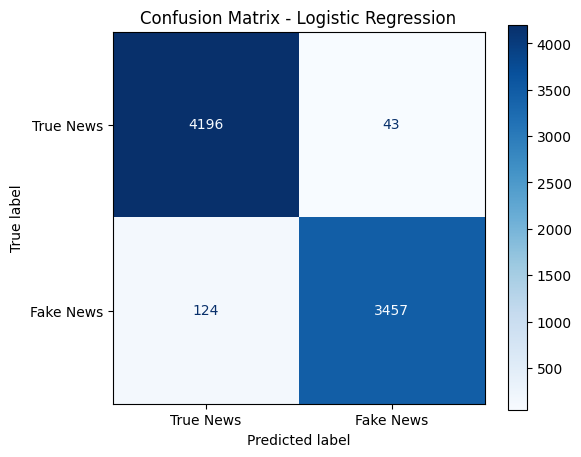

In [118]:
conf_matrix = confusion_matrix(y_test, y_pred)

conf_matrix_df = pd.DataFrame(
    conf_matrix,
    index=["Actual True News", "Actual Fake News"],
    columns=["Predicted True News", "Predicted Fake News"]
)

display(conf_matrix_df)

disp = ConfusionMatrixDisplay(
    confusion_matrix=conf_matrix,
    display_labels=["True News", "Fake News"]
)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap="Blues", values_format="d", ax=ax)
plt.title("Confusion Matrix - Logistic Regression")
plt.show()


### Observations on the Confusion Matrix

The confusion matrix confirms the good performance observed in the previous metrics.

The model correctly classified:

- **4,196 true news** as true news;
- **3,457 fake news** as fake news.

The errors made by the model are limited:

- **43 true news** were incorrectly classified as fake news;
- **124 fake news** were incorrectly classified as true news.

In the context of fake news detection, the second type of error is especially important because it represents cases where a false news item is not recognized by the model. However, compared with the total number of fake news items in the test set, the number of errors remains limited.

The confusion matrix therefore confirms that the baseline model is able to effectively distinguish the two classes on the test dataset, while still retaining some limitations related to possible biases present in the data.


## Analysis of the Most Influential Model Features

After evaluating model performance, it is useful to analyze which textual features had the greatest influence on classification.

Since Logistic Regression assigns a coefficient to each TF-IDF feature, it is possible to observe which words or word combinations contribute most to the prediction of a class.

In particular:

- higher positive coefficients indicate features that push the model toward class `1`, that is fake news;
- lower negative coefficients indicate features that push the model toward class `0`, that is true news.

This analysis makes it possible to better understand which textual patterns the model learned from the dataset. However, the results must be interpreted with caution because some features may reflect the style or source of the articles more than the actual truthfulness of the news item.


In [119]:
feature_names = tfidf_vectorizer.get_feature_names_out()
coefficients = logistic_model.coef_[0]

top_fake_indices = np.argsort(coefficients)[-20:][::-1]
top_true_indices = np.argsort(coefficients)[:20]

top_fake_features = pd.DataFrame({
    "Feature": feature_names[top_fake_indices],
    "Coefficient": coefficients[top_fake_indices]
})

top_true_features = pd.DataFrame({
    "Feature": feature_names[top_true_indices],
    "Coefficient": coefficients[top_true_indices]
})

print("Features most associated with Fake News:")
display(top_fake_features)

print("\nFeatures most associated with True News:")
display(top_true_features)


Features most associated with Fake News:


,Feature,Coefficient
0,video,9.602114
1,just,7.996228
2,gop,6.791193
3,read,6.298522
4,hillary,5.478335
5,watch,4.995269
6,president trump,4.945419
7,mr,4.885029
8,like,4.454533
9,america,4.270595



Features most associated with True News:


,Feature,Coefficient
0,said,-16.725408
1,president donald,-7.363260
2,tuesday,-5.663762
3,wednesday,-5.655368
4,thursday,-5.237044
5,republican,-4.749004
6,friday,-4.705957
7,monday,-4.094164
8,nov,-4.008062
9,presidential,-3.649908


### Observations on the Most Influential Features

The analysis of Logistic Regression coefficients makes it possible to observe which terms contributed most to news classification.

Among the features most associated with class `1`, that is fake news, terms such as the following appear:

- `video`;
- `just`;
- `gop`;
- `read`;
- `hillary`;
- `watch`;
- `president trump`;
- `mr`;
- `breaking`;
- `obama`.

These terms confirm some patterns already observed during exploratory analysis: fake news in the dataset often tends to contain more emphatic expressions, references to multimedia content, names of political figures and formulas typical of more sensationalistic articles.

An important aspect is that, after updating the cleaning function, editorial markers such as `featured image`, `getty images`, `photo by` and `image via` no longer appear among the most influential features associated with fake news. This indicates that the new cleaning process reduced some shortcuts related to the editorial structure of the articles.

Among the features most associated with class `0`, that is true news, terms such as the following appear instead:

- `said`;
- `president donald`;
- `tuesday`;
- `wednesday`;
- `thursday`;
- `republican`;
- `friday`;
- `minister`;
- `reporters`;
- `spokesman`.

These terms reflect a more journalistic and institutional style, typical of news coming from structured information sources.

This analysis is useful because it makes the model more interpretable. However, the results must be read with caution: some features may represent differences in style and source between the two datasets more than universal signals of the truthfulness of a news item.


## Training a Second Model: Linear SVM

After evaluating the first baseline model based on Logistic Regression, a second model is trained to compare performance.

In this phase, a **Linear Support Vector Machine**, often referred to as **Linear SVM**, is used. This algorithm is widely used in text classification problems because it works well with high-dimensional data, such as TF-IDF matrices.

The objective of this comparison is to verify whether a linear model different from Logistic Regression can obtain better or more balanced performance on the test set.

In this case as well, the model is trained on the training set transformed through TF-IDF and then evaluated on the test set.


In [120]:
svm_params = {
    "random_state": 42
}

svm_model = cached_train_svm_model(
    X_train_tfidf,
    y_train,
    svm_params
)

y_pred_svm = svm_model.predict(X_test_tfidf)

svm_accuracy = accuracy_score(y_test, y_pred_svm)
svm_precision = precision_score(y_test, y_pred_svm, pos_label=1)
svm_recall = recall_score(y_test, y_pred_svm, pos_label=1)
svm_f1 = f1_score(y_test, y_pred_svm, pos_label=1)

svm_main_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision (Fake News)",
        "Recall (Fake News)",
        "F1-score (Fake News)"
    ],
    "Value": [
        svm_accuracy,
        svm_precision,
        svm_recall,
        svm_f1
    ]
})

svm_classification_report_df = pd.DataFrame(
    classification_report(
        y_test,
        y_pred_svm,
        target_names=["True News", "Fake News"],
        output_dict=True
    )
).transpose()

print("Main Linear SVM metrics on the test set:")
display(svm_main_metrics.round(4))

print("\nClassification report Linear SVM:")
display(svm_classification_report_df.round(4))


Main Linear SVM metrics on the test set:


,Metric,Value
0,Accuracy,0.9839
1,Precision (Fake News),0.9876
2,Recall (Fake News),0.9771
3,F1-score (Fake News),0.9823



Classification report Linear SVM:


,precision,recall,f1-score,support
True News,0.9808,0.9896,0.9852,4239.0000
Fake News,0.9876,0.9771,0.9823,3581.0000
accuracy,0.9839,0.9839,0.9839,0.9839
macro avg,0.9842,0.9834,0.9838,7820.0000
weighted avg,0.9839,0.9839,0.9839,7820.0000


### Observations on Linear SVM Performance

The Linear SVM model obtains very high performance on the test set.

The **accuracy** is **0.9839**, therefore slightly higher than the accuracy obtained by Logistic Regression.

For class `1`, that is fake news, the model reaches:

- **precision** equal to **0.9876**;
- **recall** equal to **0.9771**;
- **F1-score** equal to **0.9823**.

Compared with Logistic Regression, Linear SVM shows an improvement especially in fake news recall. This means that the model is able to recognize a slightly larger share of the fake news present in the test set.

The classification report also confirms very balanced results between the two classes, with precision, recall and F1-score values close to **0.98** or higher.

Compared with the previous version of preprocessing, the metrics are slightly lower, but they remain very high. This is consistent with the removal of some editorial markers related to images, which could have facilitated classification through dataset-specific shortcuts.

Overall, Linear SVM is therefore slightly more performant than the first baseline model. However, in this case as well, performance must be interpreted with caution because of possible biases present in the dataset.


## Comparison between Models

After training and evaluating two linear models, it is useful to compare their performance synthetically.

The models considered are:

- **Logistic Regression**, used as the initial baseline;
- **Linear SVM**, used as a second model to verify a possible improvement in performance.

The comparison is performed using the main metrics calculated on the test set:

- accuracy;
- precision on the fake news class;
- recall on the fake news class;
- F1-score on the fake news class.

This comparison makes it possible to identify which model is more effective for fake news detection on the dataset used.


In [121]:
model_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Linear SVM"],
    "Accuracy": [accuracy, svm_accuracy],
    "Precision Fake News": [precision, svm_precision],
    "Recall Fake News": [recall, svm_recall],
    "F1-score Fake News": [f1, svm_f1]
})

display(model_comparison.round(4))


,Model,Accuracy,Precision Fake News,Recall Fake News,F1-score Fake News
0,Logistic Regression,0.9786,0.9877,0.9654,0.9764
1,Linear SVM,0.9839,0.9876,0.9771,0.9823


### Observations on the Model Comparison

The comparison shows that both models obtain very high performance on the test set.

**Logistic Regression** reaches:

- accuracy equal to **0.9786**;
- precision on fake news equal to **0.9877**;
- recall on fake news equal to **0.9654**;
- F1-score on fake news equal to **0.9764**.

**Linear SVM** reaches:

- accuracy equal to **0.9839**;
- precision on fake news equal to **0.9876**;
- recall on fake news equal to **0.9771**;
- F1-score on fake news equal to **0.9823**.

Linear SVM is therefore slightly better in terms of accuracy, recall and F1-score on fake news. In particular, the improvement in fake news recall is important because it indicates a greater ability to correctly identify false news items.

Logistic Regression instead obtains a slightly higher precision on fake news, although the difference compared with Linear SVM is minimal.

Based on this comparison, Linear SVM can be considered the best-performing model among those tested in this phase. However, Logistic Regression remains a very valid, simple and interpretable baseline.


## Comparison between the Text-Only Model and the Model with Stylistic Features

During exploratory analysis, some stylistic patterns were identified in news titles and texts, such as title length, the presence of exclamation or question marks, the number of uppercase words and the length of the news body.

To verify whether these elements concretely contribute to classification, the Linear SVM model based only on text is compared with a second version that combines text transformed through TF-IDF with the stylistic features identified during EDA.

This step makes it possible to better connect exploratory analysis to the modeling phase: the observed characteristics are not only described, but also tested as possible predictive variables.


In [122]:
# Comparison between the text-only model and the model with stylistic features

# Use the same split indices already created for the text-only model.
# In this way, the comparison is fair: the training set and test set are identical.
feature_columns = [
    "clean_content",
    "title_word_count",
    "title_has_exclamation",
    "title_has_question",
    "title_uppercase_words",
    "text_word_count"
]

X_features = df_model_features[feature_columns]
y_features = df_model_features["label"]

X_train_features = X_features.loc[X_train.index]
X_test_features = X_features.loc[X_test.index]

y_train_features = y_features.loc[y_train.index]
y_test_features = y_features.loc[y_test.index]

numeric_features = [
    "title_word_count",
    "title_has_exclamation",
    "title_has_question",
    "title_uppercase_words",
    "text_word_count"
]

text_style_model_params = {
    "random_state": 42,
    "max_iter": 3000
}

text_style_cache_signature = code_signature(
    cache_utils.train_text_and_style_svm_pipeline,
    extra=str({
        "tfidf_params": tfidf_params,
        "numeric_features": numeric_features,
        "model_params": text_style_model_params
    })
)

text_and_style_pipeline = cached_train_text_and_style_svm_pipeline(
    X_train_features,
    y_train_features,
    tfidf_params,
    numeric_features,
    text_style_model_params,
    training_signature=text_style_cache_signature
)

y_pred_text_and_style = text_and_style_pipeline.predict(X_test_features)

text_style_accuracy = accuracy_score(y_test_features, y_pred_text_and_style)
text_style_precision = precision_score(
    y_test_features,
    y_pred_text_and_style,
    pos_label=1,
    zero_division=0
)
text_style_recall = recall_score(
    y_test_features,
    y_pred_text_and_style,
    pos_label=1,
    zero_division=0
)
text_style_f1 = f1_score(
    y_test_features,
    y_pred_text_and_style,
    pos_label=1,
    zero_division=0
)

text_style_main_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision (Fake News)",
        "Recall (Fake News)",
        "F1-score (Fake News)"
    ],
    "Value": [
        text_style_accuracy,
        text_style_precision,
        text_style_recall,
        text_style_f1
    ]
})

text_style_classification_report_df = pd.DataFrame(
    classification_report(
        y_test_features,
        y_pred_text_and_style,
        target_names=["True News", "Fake News"],
        zero_division=0,
        output_dict=True
    )
).transpose()

text_vs_style_comparison = pd.DataFrame({
    "Model": [
        "Linear SVM - text only",
        "Linear SVM - text + stylistic features"
    ],
    "Accuracy": [
        svm_accuracy,
        text_style_accuracy
    ],
    "Precision Fake News": [
        svm_precision,
        text_style_precision
    ],
    "Recall Fake News": [
        svm_recall,
        text_style_recall
    ],
    "F1-score Fake News": [
        svm_f1,
        text_style_f1
    ]
})

print("Linear SVM metrics with text + stylistic features:")
display(text_style_main_metrics.round(4))

print("\nClassification report - Linear SVM with text + stylistic features:")
display(text_style_classification_report_df.round(4))

print("\nComparison between text-only model and model with stylistic features:")
display(text_vs_style_comparison.round(4))

Linear SVM metrics with text + stylistic features:


,Metric,Value
0,Accuracy,0.9946
1,Precision (Fake News),0.9969
2,Recall (Fake News),0.9913
3,F1-score (Fake News),0.9941



Classification report - Linear SVM with text + stylistic features:


,precision,recall,f1-score,support
True News,0.9927,0.9974,0.9951,4239.0000
Fake News,0.9969,0.9913,0.9941,3581.0000
accuracy,0.9946,0.9946,0.9946,0.9946
macro avg,0.9948,0.9944,0.9946,7820.0000
weighted avg,0.9946,0.9946,0.9946,7820.0000



Comparison between text-only model and model with stylistic features:


,Model,Accuracy,Precision Fake News,Recall Fake News,F1-score Fake News
0,Linear SVM - text only,0.9839,0.9876,0.9771,0.9823
1,Linear SVM - text + stylistic features,0.9946,0.9969,0.9913,0.9941


### Observations on the Comparison with Stylistic Features

The comparison shows that adding stylistic features improves performance compared with the text-only model.

The text-only Linear SVM obtains an accuracy of **0.9839**, a precision on fake news of **0.9876**, a recall of **0.9771** and an F1-score of **0.9823**.

The model that combines text and stylistic features instead reaches an accuracy of **0.9946**, a precision on fake news of **0.9969**, a recall of **0.9913** and an F1-score of **0.9941**.

The improvement is especially relevant for fake news recall, which rises from **0.9771** to **0.9913**. This means that the model with stylistic features is able to recognize a larger share of fake news present in the test set.

From an analytical point of view, this result confirms that the patterns observed during EDA, such as title length, use of emphatic punctuation and presence of uppercase words, contain useful information for distinguishing the classes in the provided dataset.

However, these features must be interpreted with caution: they may reflect the specific editorial style of the sources present in the dataset more than universal characteristics of fake news. For this reason, the model with stylistic features shows better performance, but may be more sensitive to dataset bias.

Overall, the comparison is useful because it experimentally shows that the stylistic features identified during exploratory analysis have concrete predictive value. The choice between the text-only model and the model with stylistic features therefore depends on the tradeoff between performance and ability to generalize to external sources.


## Final Model Selection

The comparison shows that the Linear SVM model with text and stylistic features obtains better performance than the text-only model.

However, the **Linear SVM based only on clean textual content** was selected as the final model.

This choice does not depend exclusively on the highest metric, but on a tradeoff between performance, integration simplicity and generalization ability. Stylistic features, such as title length, presence of exclamation marks, question marks and uppercase words, improve performance on the provided dataset, but they may reflect characteristics specific to the sources present in the dataset more than general signals of news falsity.

In a real context, such as integration into a Chrome plug-in, the model should work on news items coming from different sources. For this reason, the text-only model is considered more prudent and more suitable as the final model, because it focuses mainly on the linguistic content of the news item and reduces the risk of depending too much on stylistic patterns specific to the dataset.

The model with stylistic features remains useful as an analytical experiment because it demonstrates that the patterns identified during EDA have concrete predictive power. However, the final export uses the text-only pipeline, composed of preprocessing, TF-IDF and Linear SVM.


## Confusion Matrix of the Linear SVM Model

Since the Linear SVM based only on clean text represents the final model selected for the project, even though the model with stylistic features obtained higher metrics, we now analyze its confusion matrix.

The confusion matrix makes it possible to observe in detail how many articles were correctly classified and how many errors were made by the model.

In particular, it is useful to verify how many fake news cases were incorrectly classified as true news, because this type of error is especially relevant in the context of disinformation detection.


,Predicted True News,Predicted Fake News
Actual True News,4195,44
Actual Fake News,82,3499


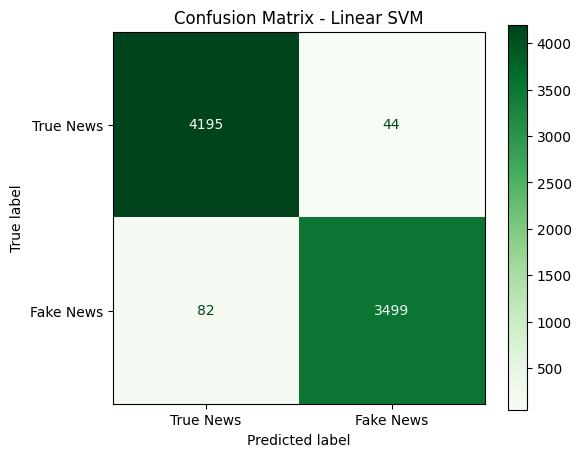

In [123]:
svm_conf_matrix = confusion_matrix(y_test, y_pred_svm)

svm_conf_matrix_df = pd.DataFrame(
    svm_conf_matrix,
    index=["Actual True News", "Actual Fake News"],
    columns=["Predicted True News", "Predicted Fake News"]
)

display(svm_conf_matrix_df)

svm_disp = ConfusionMatrixDisplay(
    confusion_matrix=svm_conf_matrix,
    display_labels=["True News", "Fake News"]
)

fig, ax = plt.subplots(figsize=(6, 5))
svm_disp.plot(cmap="Greens", values_format="d", ax=ax)
plt.title("Confusion Matrix - Linear SVM")
plt.show()


### Observations on the Linear SVM Confusion Matrix

The confusion matrix of the Linear SVM confirms the model's excellent performance.

The model correctly classified:

- **4,195 true news** as true news;
- **3,499 fake news** as fake news.

The errors made are:

- **44 true news** incorrectly classified as fake news;
- **82 fake news** incorrectly classified as true news.

Compared with Logistic Regression, Linear SVM mainly reduces the number of unrecognized fake news items, which decreases from **124** to **82**. This result is especially relevant for the objective of the project because it indicates a better ability to identify false content.

The number of true news items incorrectly classified as fake news is instead very similar to that of Logistic Regression, going from **43** to **44**.

Overall, the confusion matrix confirms that Linear SVM is the most effective model among those tested in this phase, especially because of its greater ability to recognize fake news.


## Check of Linear SVM Model Parameters

After comparing Logistic Regression and Linear SVM, a targeted check of some Linear SVM model configurations is performed.

In this phase, a completely different model is not built. Instead, some combinations of the main parameters of the TF-IDF vectorizer and the Linear SVM classifier are compared. In particular, different values of `max_features`, `ngram_range` and `C` are tested.

The objective is to verify whether an alternative configuration can improve performance compared with the Linear SVM already evaluated earlier, or whether the initial configuration already represents an adequate choice.

The search is performed on a stratified validation set, in order to maintain a consistent distribution between true news and fake news. In addition, the process is managed through a cache with `joblib.Memory`, avoiding recalculation of heavy operations in later notebook executions.

This section should therefore be interpreted as a light check of the final model parameters, not as a true extensive optimization. If the best parameters match those already used, the result does not indicate a new improvement, but confirms the robustness of the previous configuration.


Results of tested parameters:


,max_features,ngram_range,C,accuracy,precision_fake,recall_fake,f1_fake
0,5000,"(1, 2)",1.0,0.9790,0.9760,0.9782,0.9771
1,3000,"(1, 2)",0.5,0.9780,0.9791,0.9727,0.9759
2,5000,"(1, 1)",1.0,0.9775,0.9780,0.9727,0.9754
3,3000,"(1, 1)",0.5,0.9730,0.9736,0.9672,0.9704



Best parameters found:


,max_features,ngram_range,C
0,5000,"(1, 2)",1.0



Optimized model metrics on the test set:


...

,precision,recall,f1-score,support
True News,0.9808,0.9896,0.9852,4239.0000
Fake News,0.9876,0.9771,0.9823,3581.0000
accuracy,0.9839,0.9839,0.9839,0.9839
macro avg,0.9842,0.9834,0.9838,7820.0000
weighted avg,0.9839,0.9839,0.9839,7820.0000



Comparison between models:


,Model,Accuracy,Precision Fake News,Recall Fake News,F1-score Fake News
0,Logistic Regression,0.9786,0.9877,0.9654,0.9764
1,Linear SVM,0.9839,0.9876,0.9771,0.9823
2,Optimized Linear SVM,0.9839,0.9876,0.9771,0.9823



Optimized model confusion matrix:


,Predicted True News,Predicted Fake News
Actual True News,4195,44
Actual Fake News,82,3499


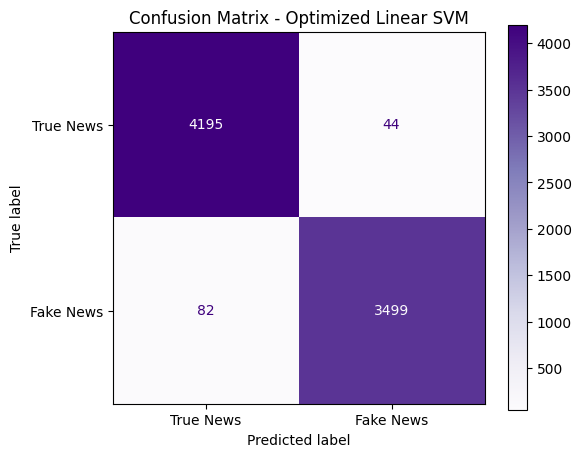

In [124]:
parameters_to_test = [
    {"max_features": 3000, "ngram_range": (1, 1), "C": 0.5},
    {"max_features": 3000, "ngram_range": (1, 2), "C": 0.5},
    {"max_features": 5000, "ngram_range": (1, 1), "C": 1.0},
    {"max_features": 5000, "ngram_range": (1, 2), "C": 1.0},
]

optimization_cache_signature = code_signature(
    optimization_cache_utils.fast_linear_svm_optimization,
    optimization_cache_utils.train_final_linear_svm_pipeline,
    extra=str(parameters_to_test)
)

optimization_results, best_params = cached_fast_linear_svm_optimization(
    X_train,
    y_train,
    train_size=8000,
    test_size=2000,
    random_state=42,
    parameter_grid=parameters_to_test,
    optimization_signature=optimization_cache_signature
)

print("Results of tested parameters:")
display(optimization_results.round(4))

best_params_df = pd.DataFrame([best_params])

print("\nBest parameters found:")
display(best_params_df)

final_pipeline = cached_train_final_linear_svm_pipeline(
    X_train,
    y_train,
    best_params,
    random_state=42,
    training_signature=optimization_cache_signature
)

final_vectorizer = final_pipeline.named_steps["tfidf"]
final_model = final_pipeline.named_steps["model"]

y_pred_final = final_pipeline.predict(X_test)

final_accuracy = accuracy_score(y_test, y_pred_final)
final_precision = precision_score(y_test, y_pred_final, pos_label=1)
final_recall = recall_score(y_test, y_pred_final, pos_label=1)
final_f1 = f1_score(y_test, y_pred_final, pos_label=1)

final_main_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision (Fake News)",
        "Recall (Fake News)",
        "F1-score (Fake News)"
    ],
    "Value": [
        final_accuracy,
        final_precision,
        final_recall,
        final_f1
    ]
})

final_classification_report_df = pd.DataFrame(
    classification_report(
        y_test,
        y_pred_final,
        target_names=["True News", "Fake News"],
        output_dict=True
    )
).transpose()

print("\nOptimized model metrics on the test set:")
display(final_main_metrics.round(4))

print("\nOptimized model classification report:")
display(final_classification_report_df.round(4))

optimized_comparison = pd.concat([
    model_comparison,
    pd.DataFrame({
        "Model": ["Optimized Linear SVM"],
        "Accuracy": [final_accuracy],
        "Precision Fake News": [final_precision],
        "Recall Fake News": [final_recall],
        "F1-score Fake News": [final_f1]
    })
], ignore_index=True)

print("\nComparison between models:")
display(optimized_comparison.round(4))

final_conf_matrix = confusion_matrix(y_test, y_pred_final)

final_conf_matrix_df = pd.DataFrame(
    final_conf_matrix,
    index=["Actual True News", "Actual Fake News"],
    columns=["Predicted True News", "Predicted Fake News"]
)

print("\nOptimized model confusion matrix:")
display(final_conf_matrix_df)

final_disp = ConfusionMatrixDisplay(
    confusion_matrix=final_conf_matrix,
    display_labels=["True News", "Fake News"]
)

fig, ax = plt.subplots(figsize=(6, 5))
final_disp.plot(cmap="Purples", values_format="d", ax=ax)
plt.title("Confusion Matrix - Optimized Linear SVM")
plt.show()

## Class-Balanced Temporal Check

After evaluating the model with a random split, an additional check based on the temporal order of the news items is added.

In this check, observations are ordered temporally separately for each class: for true news, the oldest 80% is used for training and the most recent 20% for testing; the same is done for fake news.

This choice keeps the class distribution balanced, but it does not represent a pure past-future temporal validation because the training and test periods may overlap in the calendar.

For this reason, the results of this analysis should be interpreted as a supplementary model stability check. The main temporal validation will instead be the following one with a global cutoff.


Summary of the class-balanced temporal split:


,Set,Period,Number of observations,True News,Fake News
0,Training - class-balanced temporal check,2015-03-31 -> 2017-11-13,31278,16957,14321
1,Test - class-balanced temporal check,2017-05-17 -> 2018-02-19,7821,4240,3581



Methodological note:
The training and test periods overlap between 2017-05-17 and 2017-11-13.
This analysis should therefore be interpreted as a class-balanced temporal check by class, not as a pure past-future temporal validation.

Model metrics in the class-balanced temporal check:


,Metric,Value
0,Accuracy,0.9809
1,Precision Fake News,0.9925
2,Recall Fake News,0.9657
3,F1-score Fake News,0.9789


Classification report - class-balanced temporal check:


,precision,recall,f1-score,support
True News,0.9716,0.9939,0.9826,4240
Fake News,0.9925,0.9657,0.9789,3581
accuracy,0.9809,0.9809,0.9809,7821
macro avg,0.9821,0.9798,0.9808,7821
weighted avg,0.9812,0.9809,0.9809,7821


Confusion matrix - absolute values:


,Predicted True News,Predicted Fake News
Actual True News,4214,26
Actual Fake News,123,3458


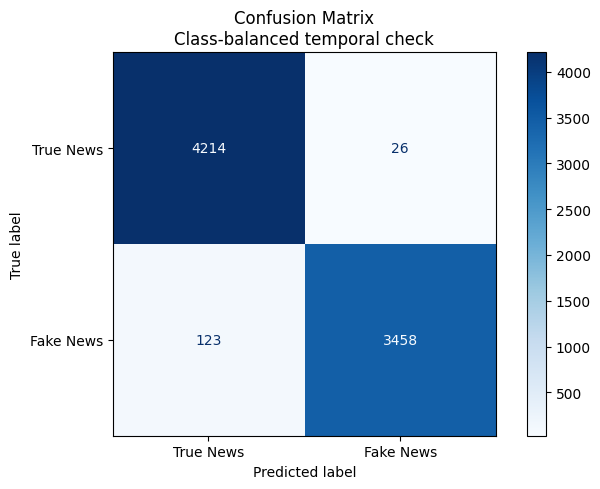

Comparison between final random split and class-balanced temporal check:


,Validation,Accuracy,Precision Fake News,Recall Fake News,F1-score Fake News
0,Final random split,0.9839,0.9876,0.9771,0.9823
1,Class-balanced temporal check,0.9809,0.9925,0.9657,0.9789


In [125]:
# Class-balanced temporal check
# This cell sorts the observations temporally and separately for each class.
# For each class, the oldest 80% is used for training and the most recent 20% for testing.
# This check keeps the class distribution balanced, but it does NOT represent
# a pure past-future temporal validation, because the training and test periods
# can overlap in the calendar.

required_columns = {"clean_content", "label", "date"}
missing_columns = required_columns - set(df_clean.columns)

if missing_columns:
    raise ValueError(f"Missing columns in df_clean: {missing_columns}")

if "date_clean" not in df_clean.columns:
    try:
        df_clean["date_clean"] = pd.to_datetime(
            df_clean["date"].astype(str).str.strip(),
            errors="coerce",
            format="mixed"
        )
    except TypeError:
        df_clean["date_clean"] = pd.to_datetime(
            df_clean["date"].astype(str).str.strip(),
            errors="coerce"
        )

temporal_df = df_clean[
    ["clean_content", "label", "date_clean"]
].dropna(subset=["date_clean", "clean_content", "label"]).copy()

temporal_df = temporal_df[
    temporal_df["clean_content"].astype(str).str.strip() != ""
].copy()

train_parts = []
test_parts = []

for label_value, class_df in temporal_df.groupby("label"):
    class_df = class_df.sort_values("date_clean").reset_index(drop=True)
    cutoff_position = int(len(class_df) * 0.80)

    train_parts.append(class_df.iloc[:cutoff_position])
    test_parts.append(class_df.iloc[cutoff_position:])

train_temporal_df = pd.concat(train_parts).sample(frac=1, random_state=42).reset_index(drop=True)
test_temporal_df = pd.concat(test_parts).sample(frac=1, random_state=42).reset_index(drop=True)

train_start = train_temporal_df["date_clean"].min()
train_end = train_temporal_df["date_clean"].max()
test_start = test_temporal_df["date_clean"].min()
test_end = test_temporal_df["date_clean"].max()

overlap_start = max(train_start, test_start)
overlap_end = min(train_end, test_end)
periods_overlap = overlap_start <= overlap_end

period_summary = pd.DataFrame({
    "Set": [
        "Training - class-balanced temporal check",
        "Test - class-balanced temporal check"
    ],
    "Period": [
        f"{train_start.date()} -> {train_end.date()}",
        f"{test_start.date()} -> {test_end.date()}"
    ],
    "Number of observations": [
        len(train_temporal_df),
        len(test_temporal_df)
    ],
    "True News": [
        (train_temporal_df["label"] == 0).sum(),
        (test_temporal_df["label"] == 0).sum()
    ],
    "Fake News": [
        (train_temporal_df["label"] == 1).sum(),
        (test_temporal_df["label"] == 1).sum()
    ]
})

print("Summary of the class-balanced temporal split:")
display(period_summary)

print("\nMethodological note:")

if periods_overlap:
    print(
        "The training and test periods overlap between "
        f"{overlap_start.date()} and {overlap_end.date()}."
    )
    print(
        "This analysis should therefore be interpreted as a class-balanced temporal check "
        "by class, not as a pure past-future temporal validation."
    )
else:
    print(
        "The training and test periods do not overlap. "
        "The split can be interpreted as a past-future temporal validation."
    )

X_train_temporal = train_temporal_df["clean_content"]
y_train_temporal = train_temporal_df["label"]

X_test_temporal = test_temporal_df["clean_content"]
y_test_temporal = test_temporal_df["label"]

if "best_params" not in globals():
    best_params = {
        "max_features": 3000,
        "ngram_range": (1, 2),
        "C": 0.5
    }

temporal_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        stop_words="english",
        max_features=int(best_params["max_features"]),
        ngram_range=tuple(best_params["ngram_range"])
    )),
    ("model", LinearSVC(
        C=float(best_params["C"]),
        random_state=42,
        max_iter=3000
    ))
])

temporal_pipeline.fit(X_train_temporal, y_train_temporal)

y_pred_temporal = temporal_pipeline.predict(X_test_temporal)

temporal_accuracy = accuracy_score(y_test_temporal, y_pred_temporal)

temporal_precision = precision_score(
    y_test_temporal,
    y_pred_temporal,
    pos_label=1,
    zero_division=0
)

temporal_recall = recall_score(
    y_test_temporal,
    y_pred_temporal,
    pos_label=1,
    zero_division=0
)

temporal_f1 = f1_score(
    y_test_temporal,
    y_pred_temporal,
    pos_label=1,
    zero_division=0
)

temporal_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision Fake News",
        "Recall Fake News",
        "F1-score Fake News"
    ],
    "Value": [
        temporal_accuracy,
        temporal_precision,
        temporal_recall,
        temporal_f1
    ]
})

print("\nModel metrics in the class-balanced temporal check:")
display(temporal_metrics.round(4))

temporal_classification_report = pd.DataFrame(
    classification_report(
        y_test_temporal,
        y_pred_temporal,
        target_names=["True News", "Fake News"],
        output_dict=True,
        zero_division=0
    )
).transpose()

temporal_classification_report = temporal_classification_report.round(4)

temporal_classification_report.loc["accuracy", "support"] = len(y_test_temporal)

temporal_classification_report["support"] = (
    temporal_classification_report["support"]
    .astype(int)
)

print("Classification report - class-balanced temporal check:")
display(temporal_classification_report)

temporal_conf_matrix = confusion_matrix(y_test_temporal, y_pred_temporal)

temporal_conf_matrix_df = pd.DataFrame(
    temporal_conf_matrix,
    index=["Actual True News", "Actual Fake News"],
    columns=["Predicted True News", "Predicted Fake News"]
)

print("Confusion matrix - absolute values:")
display(temporal_conf_matrix_df)

fig, ax = plt.subplots(figsize=(7, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test_temporal,
    y_pred_temporal,
    display_labels=["True News", "Fake News"],
    cmap="Blues",
    ax=ax
)

ax.set_title("Confusion Matrix\nClass-balanced temporal check")
plt.tight_layout()
plt.show()

if all(metric in globals() for metric in ["final_accuracy", "final_precision", "final_recall", "final_f1"]):
    validation_comparison = pd.DataFrame({
        "Validation": [
            "Final random split",
            "Class-balanced temporal check"
        ],
        "Accuracy": [
            final_accuracy,
            temporal_accuracy
        ],
        "Precision Fake News": [
            final_precision,
            temporal_precision
        ],
        "Recall Fake News": [
            final_recall,
            temporal_recall
        ],
        "F1-score Fake News": [
            final_f1,
            temporal_f1
        ]
    })

    print("Comparison between final random split and class-balanced temporal check:")
    display(validation_comparison.round(4))
else:
    print(
        "\nComparison not shown because the final metrics of the random split "
        "are not available yet."
    )


## Observations on the Class-Balanced Temporal Check

The class-balanced temporal check shows that the model maintains high performance even when observations are ordered temporally within each class.

In this check, the training set contains 31,278 observations, while the test set contains 7,821 observations. The class distribution remains balanced: the test set contains 4,240 true news and 3,581 fake news.

However, it is important to observe that the training and test periods overlap. The training set covers the period from March 31, 2015 to November 13, 2017, while the test set covers the period from May 17, 2017 to February 19, 2018. The overlap therefore goes from May 17, 2017 to November 13, 2017.

For this reason, this analysis does not represent a pure past-future temporal validation. It is more correct to interpret it as a supplementary stability check for the model, useful because it keeps the distribution between true news and fake news balanced.

The metrics remain very high:

- accuracy equal to **0.9809**;
- precision on fake news equal to **0.9925**;
- recall on fake news equal to **0.9657**;
- F1-score on fake news equal to **0.9789**.

Compared with the final random split, accuracy goes from **0.9839** to **0.9809**, while the F1-score on fake news goes from **0.9823** to **0.9789**. The reduction is limited and suggests that the model maintains good stability even with a split more connected to the temporal dimension.

The confusion matrix shows that the model correctly classifies **4,214 true news** and **3,458 fake news**. The main errors are **123 fake news classified as true news**, that is false negatives with respect to the fake news class, and **26 true news classified as fake news**.

Overall, this check strengthens the model analysis, but it should not be considered the main temporal validation. To better simulate a real scenario in which the model is trained on past news and applied to future news, the next step uses temporal validation with a global cutoff.


## Temporal Validation with a Global Cutoff

In addition to class-stratified temporal validation, a temporal validation with a global cutoff is added.

In this case, the dataset is ordered chronologically and split using a single separation date: all news items before or equal to the cutoff are used for training, while all later news items are used for testing.

This setting is more severe and closer to a real scenario, because the model is trained only on past news and evaluated on news published later.


Global cutoff: 2017-10-18

Summary of the global temporal split:


,Set,Period,Number of observations,True News,Fake News
0,Global temporal training,2015-03-31 -> 2017-10-18,31405,14399,17006
1,Global temporal test,2017-10-19 -> 2018-02-19,7694,6798,896


Percentage class distribution:


,Global training (%),Global test (%)
True News,45.85,88.35
Fake News,54.15,11.65



Model metrics with global temporal cutoff:


,Metric,Value
0,Accuracy,0.9899
1,Precision Fake News,0.9360
2,Recall Fake News,0.9799
3,F1-score Fake News,0.9575


Classification report - global temporal cutoff:


,precision,recall,f1-score,support
True News,0.9973,0.9912,0.9942,6798
Fake News,0.9360,0.9799,0.9575,896
accuracy,0.9899,0.9899,0.9899,7694
macro avg,0.9667,0.9855,0.9759,7694
weighted avg,0.9902,0.9899,0.9900,7694


Confusion matrix - absolute values:


,Predicted True News,Predicted Fake News
Actual True News,6738,60
Actual Fake News,18,878


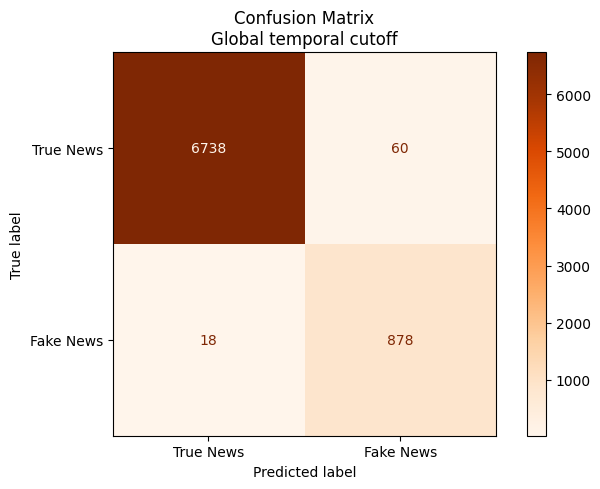

Overall comparison between validation strategies:


,Validation,Accuracy,Precision Fake News,Recall Fake News,F1-score Fake News
0,Final random split,0.9839,0.9876,0.9771,0.9823
1,Class-balanced temporal check,0.9809,0.9925,0.9657,0.9789
2,Global temporal cutoff,0.9899,0.9360,0.9799,0.9575


In [126]:
# Temporal validation with a global cutoff
# Objective: train the model on the past and test it on the future.

required_columns = {"clean_content", "label", "date"}
missing_columns = required_columns - set(df_clean.columns)

if missing_columns:
    raise ValueError(f"Missing columns in df_clean: {missing_columns}")

# If date_clean does not exist, it is recreated
if "date_clean" not in df_clean.columns:
    try:
        df_clean["date_clean"] = pd.to_datetime(
            df_clean["date"].astype(str).str.strip(),
            errors="coerce",
            format="mixed"
        )
    except TypeError:
        df_clean["date_clean"] = pd.to_datetime(
            df_clean["date"].astype(str).str.strip(),
            errors="coerce"
        )

# Temporally sorted dataset
temporal_global_df = df_clean[
    ["clean_content", "label", "date_clean"]
].dropna(subset=["clean_content", "label", "date_clean"]).copy()

temporal_global_df = temporal_global_df[
    temporal_global_df["clean_content"].astype(str).str.strip() != ""
].copy()

temporal_global_df = temporal_global_df.sort_values("date_clean").reset_index(drop=True)

# Global cutoff: approximately the oldest 80% of the data in training, the most recent 20% in test
cutoff_index = int(len(temporal_global_df) * 0.80)
cutoff_date = temporal_global_df.loc[cutoff_index, "date_clean"]

train_global_df = temporal_global_df[
    temporal_global_df["date_clean"] <= cutoff_date
].copy()

test_global_df = temporal_global_df[
    temporal_global_df["date_clean"] > cutoff_date
].copy()

train_global_start = train_global_df["date_clean"].min()
train_global_end = train_global_df["date_clean"].max()
test_global_start = test_global_df["date_clean"].min()
test_global_end = test_global_df["date_clean"].max()

global_temporal_summary = pd.DataFrame({
    "Set": [
        "Global temporal training",
        "Global temporal test"
    ],
    "Period": [
        f"{train_global_start.date()} -> {train_global_end.date()}",
        f"{test_global_start.date()} -> {test_global_end.date()}"
    ],
    "Number of observations": [
        len(train_global_df),
        len(test_global_df)
    ],
    "True News": [
        (train_global_df["label"] == 0).sum(),
        (test_global_df["label"] == 0).sum()
    ],
    "Fake News": [
        (train_global_df["label"] == 1).sum(),
        (test_global_df["label"] == 1).sum()
    ]
})

print("Global cutoff:", cutoff_date.date())

print("\nSummary of the global temporal split:")
display(global_temporal_summary)

global_class_distribution = pd.DataFrame({
    "Global training (%)": train_global_df["label"].value_counts(normalize=True).sort_index() * 100,
    "Global test (%)": test_global_df["label"].value_counts(normalize=True).sort_index() * 100
})

global_class_distribution.index = ["True News", "Fake News"]

print("Percentage class distribution:")
display(global_class_distribution.round(2))

X_train_global = train_global_df["clean_content"]
y_train_global = train_global_df["label"]

X_test_global = test_global_df["clean_content"]
y_test_global = test_global_df["label"]

# Parameters consistent with the optimized final model
if "best_params" not in globals():
    best_params = {
        "max_features": 3000,
        "ngram_range": (1, 2),
        "C": 0.5
    }

global_temporal_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        stop_words="english",
        max_features=int(best_params["max_features"]),
        ngram_range=tuple(best_params["ngram_range"])
    )),
    ("model", LinearSVC(
        C=float(best_params["C"]),
        random_state=42,
        max_iter=3000
    ))
])

global_temporal_pipeline.fit(X_train_global, y_train_global)

y_pred_global = global_temporal_pipeline.predict(X_test_global)

global_temporal_accuracy = accuracy_score(y_test_global, y_pred_global)

global_temporal_precision = precision_score(
    y_test_global,
    y_pred_global,
    pos_label=1,
    zero_division=0
)

global_temporal_recall = recall_score(
    y_test_global,
    y_pred_global,
    pos_label=1,
    zero_division=0
)

global_temporal_f1 = f1_score(
    y_test_global,
    y_pred_global,
    pos_label=1,
    zero_division=0
)

global_temporal_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision Fake News",
        "Recall Fake News",
        "F1-score Fake News"
    ],
    "Value": [
        global_temporal_accuracy,
        global_temporal_precision,
        global_temporal_recall,
        global_temporal_f1
    ]
})

print("\nModel metrics with global temporal cutoff:")
display(global_temporal_metrics.round(4))

global_temporal_classification_report = pd.DataFrame(
    classification_report(
        y_test_global,
        y_pred_global,
        labels=[0, 1],
        target_names=["True News", "Fake News"],
        output_dict=True,
        zero_division=0
    )
).transpose()

global_temporal_classification_report = global_temporal_classification_report.round(4)

global_temporal_classification_report.loc["accuracy", "support"] = len(y_test_global)

global_temporal_classification_report["support"] = (
    global_temporal_classification_report["support"]
    .astype(int)
)

print("Classification report - global temporal cutoff:")
display(global_temporal_classification_report)

global_temporal_conf_matrix = confusion_matrix(
    y_test_global,
    y_pred_global,
    labels=[0, 1]
)

global_temporal_conf_matrix_df = pd.DataFrame(
    global_temporal_conf_matrix,
    index=["Actual True News", "Actual Fake News"],
    columns=["Predicted True News", "Predicted Fake News"]
)

print("Confusion matrix - absolute values:")
display(global_temporal_conf_matrix_df)

fig, ax = plt.subplots(figsize=(7, 5))

global_temporal_disp = ConfusionMatrixDisplay(
    confusion_matrix=global_temporal_conf_matrix,
    display_labels=["True News", "Fake News"]
)

global_temporal_disp.plot(
    cmap="Oranges",
    values_format="d",
    ax=ax
)

ax.set_title("Confusion Matrix\nGlobal temporal cutoff")
plt.tight_layout()
plt.show()

# Comparison with the validations already calculated in the notebook
validation_rows = []

if all(metric in globals() for metric in ["final_accuracy", "final_precision", "final_recall", "final_f1"]):
    validation_rows.append({
        "Validation": "Final random split",
        "Accuracy": final_accuracy,
        "Precision Fake News": final_precision,
        "Recall Fake News": final_recall,
        "F1-score Fake News": final_f1
    })

if all(metric in globals() for metric in ["temporal_accuracy", "temporal_precision", "temporal_recall", "temporal_f1"]):
    validation_rows.append({
        "Validation": "Class-balanced temporal check",
        "Accuracy": temporal_accuracy,
        "Precision Fake News": temporal_precision,
        "Recall Fake News": temporal_recall,
        "F1-score Fake News": temporal_f1
    })

validation_rows.append({
    "Validation": "Global temporal cutoff",
    "Accuracy": global_temporal_accuracy,
    "Precision Fake News": global_temporal_precision,
    "Recall Fake News": global_temporal_recall,
    "F1-score Fake News": global_temporal_f1
})

validation_comparison_extended = pd.DataFrame(validation_rows)

print("Overall comparison between validation strategies:")
display(validation_comparison_extended.round(4))


### Observations on Temporal Validation with a Global Cutoff

The temporal validation with a global cutoff uses a single separation date to divide the dataset into training set and test set.

In this specific case, the identified cutoff is **October 18, 2017**. Consequently:

- the training set contains news published from **March 31, 2015** to **October 18, 2017**;
- the test set contains news published from **October 19, 2017** to **February 19, 2018**.

This setting is more severe than the random split and the class-stratified temporal validation because it ensures that the model is trained only on news that is temporally earlier than the news used for evaluation.

The global training set contains **31,405 observations**, divided into:

- **14,399 true news**;
- **17,006 fake news**.

The global test set instead contains **7,694 observations**, divided into:

- **6,798 true news**;
- **896 fake news**.

The percentage class distribution shows an important aspect: in the training set, the classes are relatively balanced, with about **45.85% true news** and **54.15% fake news**. In the test set, however, the distribution changes clearly: true news represents about **88.35%** of the observations, while fake news represents only about **11.65%**.

This result indicates that class distribution changes over time. In particular, the most recent part of the dataset contains many more true news items than fake news items.

The model still maintains high performance even in this stricter validation:

- **accuracy** equal to **0.9899**;
- **precision on fake news** equal to **0.9360**;
- **recall on fake news** equal to **0.9799**;
- **F1-score on fake news** equal to **0.9575**.

The confusion matrix shows that the model correctly classifies **6,738 true news** and **878 fake news**. The errors are:

- **60 true news** incorrectly classified as fake news;
- **18 fake news** incorrectly classified as true news.

For this reason, in validation with a global cutoff, accuracy must be interpreted with greater caution. A high accuracy value could in fact be influenced by the imbalance of the test set toward the true news class.

In this scenario, the metrics related to the `Fake News` class therefore become especially important, particularly **recall** and **F1-score**, because they make it possible to understand whether the model is still able to correctly recognize fake news even when it is less represented in the test set.


## Naive Baseline for Global Cutoff Validation

Since the test set of the global cutoff validation is strongly imbalanced toward the `True News` class, it is useful to compare the final model with a very simple baseline.

In this baseline, the classifier always predicts `True News` for all observations in the test set.

This comparison is used to verify whether the model's high accuracy depends only on the imbalance of the test set or whether the model is truly able to recognize fake news as well.


In [127]:
# Naive baseline for validation with a global cutoff
# Compare the final model with a classifier that always predicts "True News".

dummy_global_predictions = [0] * len(y_test_global)

dummy_global_accuracy = accuracy_score(y_test_global, dummy_global_predictions)
dummy_global_precision = precision_score(
    y_test_global,
    dummy_global_predictions,
    pos_label=1,
    zero_division=0
)
dummy_global_recall = recall_score(
    y_test_global,
    dummy_global_predictions,
    pos_label=1,
    zero_division=0
)
dummy_global_f1 = f1_score(
    y_test_global,
    dummy_global_predictions,
    pos_label=1,
    zero_division=0
)

baseline_global_comparison = pd.DataFrame({
    "Model": [
        "Naive baseline: always True News",
        "Linear SVM with global cutoff"
    ],
    "Accuracy": [
        dummy_global_accuracy,
        global_temporal_accuracy
    ],
    "Precision Fake News": [
        dummy_global_precision,
        global_temporal_precision
    ],
    "Recall Fake News": [
        dummy_global_recall,
        global_temporal_recall
    ],
    "F1-score Fake News": [
        dummy_global_f1,
        global_temporal_f1
    ]
})

display(baseline_global_comparison.round(4))


,Model,Accuracy,Precision Fake News,Recall Fake News,F1-score Fake News
0,Naive baseline: always True News,0.8835,0.000,0.0000,0.0000
1,Linear SVM with global cutoff,0.9899,0.936,0.9799,0.9575


### Observations on the Global Temporal Baseline

Since the test set obtained with the global cutoff is strongly imbalanced toward the `True News` class, a comparison was added with a naive baseline that always predicts `True News`.

This baseline obtains an accuracy of **0.8835**. This value appears high, but it depends on the fact that most observations in the global test set belong to the `True News` class. In fact, the baseline does not recognize any fake news and obtains:

- **precision on fake news** equal to **0.0000**;
- **recall on fake news** equal to **0.0000**;
- **F1-score on fake news** equal to **0.0000**.

The Linear SVM model with global cutoff instead obtains clearly better results:

- **accuracy** equal to **0.9899**;
- **precision on fake news** equal to **0.9360**;
- **recall on fake news** equal to **0.9799**;
- **F1-score on fake news** equal to **0.9575**.

This comparison confirms that accuracy alone is not sufficient to correctly evaluate the model in the presence of imbalanced classes. The baseline reaches a good accuracy simply by always predicting the most frequent class, but completely fails to recognize fake news.

Linear SVM, instead, maintains a good ability to identify fake news even in a more realistic temporal scenario and with an imbalanced test set. This strengthens the evaluation of the final model because it shows that its performance does not depend only on a favorable class distribution.


## Exporting the Complete Pipeline for the Plug-in

After comparing the models, the **Linear SVM based only on clean text** was selected as the final model for the project.

This choice is consistent with what was observed in the previous section: the model with stylistic features obtains higher performance on the provided dataset, but it may be more sensitive to biases related to the editorial style of the sources. For this reason, the final export uses the text-only model, which represents a more prudent compromise between performance, integration simplicity and generalization ability.

In order to use the model in a later phase, for example in an application or Chrome plug-in, saving only the trained model is not sufficient. It is also necessary to save the entire preprocessing workflow used during training.

For this reason, four artifacts are exported:

- the complete pipeline, containing text preprocessing, the TF-IDF vectorizer and the text-only Linear SVM model;
- the final Linear SVM model;
- the final TF-IDF vectorizer;
- the Python module `fake_news_pipeline_components.py`, required to correctly reload the exported pipeline.

The exported pipeline therefore corresponds to the Linear SVM model based only on clean text. The model with stylistic features is not exported despite its superior performance, because those features may be more sensitive to dataset biases and less robust on external sources.

The main file to use during integration is therefore `fake_news_final_pipeline.pkl`, because it automatically applies to a new news item the same steps used during training.


In [128]:
models_dir = PROJECT_DIR / "models"
models_dir.mkdir(parents=True, exist_ok=True)

pipeline_components_path = models_dir / "fake_news_pipeline_components.py"

pipeline_components_code = r'''
import re
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin


def clean_text(text):
    text = str(text)

    text = re.sub(
        r"\b[A-Z][A-Z./&' -]{1,100}(?:,\s*[A-Za-z .'-]{2,80})?\s+\(Reuters\)\s*-\s*",
        " ",
        text
    )

    text = re.sub(r"\(Reuters\)\s*-\s*", " ", text)
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"\[(?:/?vc_[^\]]*|/?td_[^\]]*)\]", " ", text)

    text = re.sub(
        r"\bfeatured\s+image\b[:\s-]*[^.!?\n]{0,200}",
        " ",
        text,
        flags=re.IGNORECASE
    )

    text = re.sub(
        r"\bimage\s+via\b[:\s-]*[^.!?\n]{0,200}",
        " ",
        text,
        flags=re.IGNORECASE
    )

    text = re.sub(
        r"\bphoto\s+by\b[:\s-]*[^.!?\n]{0,200}",
        " ",
        text,
        flags=re.IGNORECASE
    )

    text = re.sub(
        r"\bphoto\s+via\b[:\s-]*[^.!?\n]{0,200}",
        " ",
        text,
        flags=re.IGNORECASE
    )

    text = re.sub(
        r"\bgetty\s+images?\b",
        " ",
        text,
        flags=re.IGNORECASE
    )

    text = text.lower()
    text = re.sub(r"\breuters\b", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text


class RawNewsTextPreprocessor(BaseEstimator, TransformerMixin):
    def __init__(self, title_col="title", text_col="text"):
        self.title_col = title_col
        self.text_col = text_col

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()

        content = (
            X[self.title_col].fillna("").astype(str).str.strip()
            + " "
            + X[self.text_col].fillna("").astype(str).str.strip()
        ).str.strip()

        return content.apply(clean_text)
'''

pipeline_components_path.write_text(pipeline_components_code, encoding="utf-8")

if str(models_dir) in sys.path:
    sys.path.remove(str(models_dir))

sys.path.insert(0, str(models_dir))
importlib.invalidate_caches()

if "fake_news_pipeline_components" in sys.modules:
    del sys.modules["fake_news_pipeline_components"]

import fake_news_pipeline_components

RawNewsTextPreprocessor = fake_news_pipeline_components.RawNewsTextPreprocessor

final_pipeline_for_plugin = Pipeline([
    ("preprocess", RawNewsTextPreprocessor(title_col="title", text_col="text")),
    ("tfidf", final_vectorizer),
    ("model", final_model)
])

pipeline_path = models_dir / "fake_news_final_pipeline.pkl"
model_path = models_dir / "fake_news_final_model.pkl"
vectorizer_path = models_dir / "tfidf_final_vectorizer.pkl"

with open(pipeline_path, "wb") as pipeline_file:
    pickle.dump(final_pipeline_for_plugin, pipeline_file)

with open(model_path, "wb") as model_file:
    pickle.dump(final_model, model_file)

with open(vectorizer_path, "wb") as vectorizer_file:
    pickle.dump(final_vectorizer, vectorizer_file)

print("Complete pipeline for the plug-in saved in:", pipeline_path)
print("Final model saved in:", model_path)
print("TF-IDF vectorizer saved in:", vectorizer_path)
print("Preprocessing module saved in:", pipeline_components_path)


Complete pipeline for the plug-in saved in: /content/fake_news_project/models/fake_news_final_pipeline.pkl
Final model saved in: /content/fake_news_project/models/fake_news_final_model.pkl
TF-IDF vectorizer saved in: /content/fake_news_project/models/tfidf_final_vectorizer.pkl
Preprocessing module saved in: /content/fake_news_project/models/fake_news_pipeline_components.py


In [129]:
models_dir = PROJECT_DIR / "models"

if str(models_dir) not in sys.path:
    sys.path.insert(0, str(models_dir))

with open(models_dir / "fake_news_final_pipeline.pkl", "rb") as pipeline_file:
    loaded_pipeline = pickle.load(pipeline_file)

example_news = pd.DataFrame([
    {
        "title": "Trump announces new political decision",
        "text": "The article text goes here. This is the raw text collected from the web page."
    }
])

example_prediction = loaded_pipeline.predict(example_news)

print("Example prediction:", example_prediction[0])
print("0 = True News, 1 = Fake News")

clean_environment_test = f"""
import pickle
import sys
from pathlib import Path
import pandas as pd

models_dir = Path(r'{str(models_dir)}')
sys.path.insert(0, str(models_dir))

with open(models_dir / "fake_news_final_pipeline.pkl", "rb") as pipeline_file:
    pipeline = pickle.load(pipeline_file)

example_news = pd.DataFrame([
    {{
        "title": "Trump announces new political decision",
        "text": "The article text goes here. This is the raw text collected from the web page."
    }}
])

prediction = pipeline.predict(example_news)

print("Loading successful in a clean environment.")
print("Example prediction:", prediction[0])
"""

result = subprocess.run(
    [sys.executable, "-c", clean_environment_test],
    cwd=str(Path.home()),
    capture_output=True,
    text=True
)

if result.returncode != 0:
    print(result.stderr)
    raise RuntimeError("Error while loading the pipeline in a clean environment.")

print(result.stdout)


Example prediction: 1
0 = True News, 1 = Fake News
Loading successful in a clean environment.
Example prediction: 1



## Observations on Model Export

The export process was completed correctly.

Four main artifacts were saved:

- `fake_news_final_pipeline.pkl`, containing the complete plug-in pipeline composed of text preprocessing, TF-IDF vectorizer and final Linear SVM model;
- `fake_news_final_model.pkl`, containing only the trained final model;
- `tfidf_final_vectorizer.pkl`, containing only the final TF-IDF vectorizer used to transform text into numerical format;
- `fake_news_pipeline_components.py`, containing the preprocessing module needed to correctly load and use the exported pipeline.

The most complete file for later use is `fake_news_final_pipeline.pkl`, because it preserves the entire workflow applied during training: text cleaning, TF-IDF transformation and final classification.

Saving the model and vectorizer separately is still useful for possible technical checks, later analyses or more customized integrations.

The pipeline loading test confirms that the exported file can be reloaded correctly and applied to a new news item. The example prediction returns `1`, that is `Fake News`, showing that the pipeline is ready to be used in a later integration phase, for example inside an application or Chrome plug-in.

From the integration point of view, it is important to specify that the `.pkl` file cannot be used directly inside the Chrome browser. The pickle format is designed to be loaded in a Python environment. For a real future integration into the Chrome plug-in, a Python backend or a dedicated API would therefore be required.

In this scenario, the Chrome plug-in would collect the title and text of the news item displayed to the user and send them to the backend. The backend would load the exported pipeline, apply preprocessing, run the prediction and return the final result to the plug-in, for example `True News` or `Fake News`.

The logical structure of the integration would therefore be:

`Chrome plug-in -> Python API/backend -> pickle pipeline -> True/Fake response`


## Conclusions of the Third Phase

In this third phase, a Machine Learning model for fake news detection was developed and evaluated.

The work started from the `df_model_text` dataset, created in the previous phase and composed of:

- `clean_content`, that is, the clean text of the news item;
- `label`, that is, the news class.

The dataset was split into training set and test set using a stratified split. This choice made it possible to maintain the same proportion between true news and fake news in both sets.

The text was then transformed into a numerical representation through TF-IDF. The vectorizer was trained exclusively on the training set and then applied to the test set, avoiding data leakage.

Several models were trained and compared, including:

- **Logistic Regression**, used as the initial baseline;
- **text-only Linear SVM**, used as the main model;
- **Linear SVM with stylistic features**, used as an additional experiment to evaluate the contribution of patterns identified during EDA.

Logistic Regression reached an accuracy of **0.9786**, while the text-only Linear SVM obtained an accuracy of **0.9839**. The text-only model also reached a precision on fake news of **0.9876**, a recall of **0.9771** and an F1-score of **0.9823**.

The model with stylistic features obtained higher metrics on the provided dataset. However, the **text-only Linear SVM** was selected for the final export because it represents a more prudent compromise between performance, integration simplicity and lower dependence on stylistic patterns potentially connected to the dataset sources.

The confusion matrix of the text-only Linear SVM confirmed very good results, showing a limited number of errors. In particular, the model correctly classified **3,499 fake news** and incorrectly classified **82 fake news** as true news.

The final model and the TF-IDF vectorizer were exported in pickle format, so that they can be reused in a later integration phase.

It is important to emphasize that the performance obtained is very high on the dataset used. However, it must be interpreted with caution because possible biases related to article source, editorial style and dataset structure were identified in the previous phases. For this reason, the model can be considered effective in the context of the analyzed data, but before real-world use it would be appropriate to test it on external and more heterogeneous data.


In [130]:
# Final project summary

summary_dataset = pd.DataFrame({
    "Step": [
        "Original dataset",
        "Dataset after removing textual duplicates",
        "Final dataset after preprocessing",
        "Training set",
        "Test set"
    ],
    "Number of observations": [
        df.shape[0],
        39105,
        df_model_text.shape[0],
        X_train.shape[0],
        X_test.shape[0]
    ]
})

display(summary_dataset)

summary_classes = pd.DataFrame({
    "Class": ["True News", "Fake News"],
    "Label": [0, 1],
    "Number of observations": df_model_text["label"].value_counts().sort_index().values,
    "Percentage": (
        df_model_text["label"]
        .value_counts(normalize=True)
        .sort_index()
        .values * 100
    ).round(2)
})

display(summary_classes)

summary_models = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Linear SVM",
        "Optimized Linear SVM"
    ],
    "Accuracy": [
        accuracy,
        svm_accuracy,
        final_accuracy
    ],
    "Precision Fake News": [
        precision,
        svm_precision,
        final_precision
    ],
    "Recall Fake News": [
        recall,
        svm_recall,
        final_recall
    ],
    "F1-score Fake News": [
        f1,
        svm_f1,
        final_f1
    ]
})

display(summary_models.round(4))

final_project_summary = pd.DataFrame({
    "Element": [
        "Text representation technique",
        "Selected final model",
        "Best parameters",
        "Final accuracy",
        "Final precision on Fake News",
        "Final recall on Fake News",
        "Final F1-score on Fake News",
        "Exported pipeline",
        "Exported model",
        "Exported vectorizer"
    ],
    "Result": [
        "TF-IDF",
        "Linear SVM",
        str(best_params),
        round(final_accuracy, 4),
        round(final_precision, 4),
        round(final_recall, 4),
        round(final_f1, 4),
        "fake_news_final_pipeline.pkl",
        "fake_news_final_model.pkl",
        "tfidf_final_vectorizer.pkl"
    ]
})

display(final_project_summary)


,Step,Number of observations
0,Original dataset,44898
1,Dataset after removing textual duplicates,39105
2,Final dataset after preprocessing,39100
3,Training set,31280
4,Test set,7820


,Class,Label,Number of observations,Percentage
0,True News,0,21197,54.21
1,Fake News,1,17903,45.79


,Model,Accuracy,Precision Fake News,Recall Fake News,F1-score Fake News
0,Logistic Regression,0.9786,0.9877,0.9654,0.9764
1,Linear SVM,0.9839,0.9876,0.9771,0.9823
2,Optimized Linear SVM,0.9839,0.9876,0.9771,0.9823


,Element,Result
0,Text representation technique,TF-IDF
1,Selected final model,Linear SVM
2,Best parameters,"{'max_features': 5000, 'ngram_range': (1, 2), ..."
3,Final accuracy,0.9839
4,Final precision on Fake News,0.9876
5,Final recall on Fake News,0.9771
6,Final F1-score on Fake News,0.9823
7,Exported pipeline,fake_news_final_pipeline.pkl
8,Exported model,fake_news_final_model.pkl
9,Exported vectorizer,tfidf_final_vectorizer.pkl


## Final Conclusion

The project aimed to develop a Machine Learning model for automatic fake news detection, in line with the proposed project brief. The work was organized into three main phases: data analysis, text cleaning and preprocessing, and model training and evaluation.

In the first phase, the two provided datasets were analyzed, containing true news and fake news. The original dataset was composed of 44,898 observations. During exploratory analysis, duplicates, empty texts, URLs, HTML elements, shortcodes and possible data quality issues were identified. A strong association also emerged between some variables and the target class, especially the Reuters source and the `subject` column. To avoid possible forms of data leakage, this information was used only for exploratory purposes and not as a feature of the final model.

In the second phase, a single textual variable was built by combining the title and body of the news item. The text was then cleaned by removing URLs, explicit Reuters source references, HTML elements, shortcodes, editorial markers and extra spaces. After removing textual duplicates and non-informative contents, the final dataset used for modeling contained 39,100 observations, of which 21,197 were true news and 17,903 were fake news. The class distribution remained sufficiently balanced, with 54.21% true news and 45.79% fake news.

In the third phase, the dataset was split into training set and test set with a stratified split, keeping 80% of the data for training and 20% for evaluation. The text was transformed into a numerical representation through TF-IDF, a technique suitable for emphasizing the most informative terms inside documents. Several models were then trained and compared, especially Logistic Regression and Linear SVM.

The results obtained on the stratified random split show very high performance. Logistic Regression reached an accuracy of 0.9786 and an F1-score on fake news of 0.9764. The text-only Linear SVM obtained slightly better results, with an accuracy of 0.9839, a precision on fake news of 0.9876, a recall of 0.9771 and an F1-score of 0.9823. The optimized Linear SVM also confirmed the same performance.

During modeling, a Linear SVM model with additional stylistic features was also tested, such as title length, presence of exclamation or question marks, uppercase words and text length. This model obtained higher metrics on the provided dataset. However, the text-only Linear SVM was selected as the final model not because it has the highest metric in absolute terms, but because it offers a good balance between high performance, ease of use and lower dependence on stylistic features potentially related to the sources and structure of the dataset.

To better evaluate the model's ability to generalize over time, a temporal validation with a global cutoff was also performed. In this more realistic scenario, the model was trained on older news and tested on later news. In this configuration as well, Linear SVM maintained good performance, with an accuracy of 0.9899, a precision on fake news of 0.9360, a recall of 0.9799 and an F1-score of 0.9575. This result strengthens the quality of the model, while also highlighting that the metrics must be interpreted with caution because of the temporal imbalance in the test set.

The final model uses a pipeline composed of text preprocessing, TF-IDF and text-only Linear SVM. The choice not to export the model with stylistic features is motivated by the intention to reduce the risk that the classifier depends on patterns that are too specific to the dataset, such as title length, uppercase usage or emphatic punctuation. The pipeline was exported in the file `fake_news_final_pipeline.pkl`, together with the separate model and vectorizer in the files `fake_news_final_model.pkl` and `tfidf_final_vectorizer.pkl`. This makes it possible to reuse the model in a later integration phase, for example through a backend connected to a Chrome plug-in.

In conclusion, the project achieved the main objective of the brief: building, evaluating and exporting an NLP model able to distinguish true and fake news with high performance on the provided dataset. However, the results must be interpreted carefully because the dataset presents biases related to article source, editorial style and category structure. Before real-world use, it would therefore be appropriate to validate the model on external, more recent data from different sources, in order to verify its ability to generalize to news not present in the original dataset.

### Model Limitations

It is important to emphasize that the developed model does not verify the truth of a news item in an absolute sense. The system does not perform fact-checking on the reported facts, does not consult external sources and does not compare claims in the article with official or updated data.

The model instead learns linguistic and statistical patterns present in the dataset used for training. Consequently, the excellent performance obtained indicates that the classifier is very effective at distinguishing true and fake news within the provided data, but it does not automatically guarantee the same accuracy on new, more recent news or news from different sources.

In particular, the dataset presents possible biases related to article source, editorial style, temporal distribution and news categories. Even after removing explicit signals such as the Reuters reference and after excluding the `subject` column from the final model, stylistic or lexical differences may remain and be used by the model to classify news items.

For this reason, the model should be interpreted as a support tool for detecting potentially unreliable content, not as a definitive system for verifying truthfulness. Before possible real use, for example in a Chrome plug-in, it would need to be validated on external, more recent data from heterogeneous sources.

### Dataset Bias

An important aspect that emerged during the analysis concerns the presence of possible biases in the dataset. In particular, some information is strongly associated with the news class. For example, the Reuters reference is very frequent in true news and almost absent in fake news. Similarly, the `subject` column contains categories distributed separately between the two classes.

To reduce this risk, the final model does not use the `subject` column and the preprocessing function removes explicit Reuters references from the text. However, this choice does not completely eliminate the problem. Even after cleaning, the model could learn indirect differences related to the editorial style of the sources: for example, journalistic tone, sentence structure, use of recurring words, title length or the presence of formulas typical of a specific source.

Consequently, part of the high performance may depend not only on the model's ability to recognize false content, but also on its ability to distinguish the style of the sources present in the dataset. This does not make the model useless, but it requires caution when interpreting the results.

For real-world use, it would therefore be necessary to test the model on news from new, more recent and more varied sources, in order to verify whether the classifier can generalize beyond the specific characteristics of the training dataset.
